
# Chapter 4 - Advanced Concepts in Diffusion

After this chapter you should be able to:

1. Understand that **error** minimization in reverse diffusion is related to **ELBO**
2. Define and visualize what is a **score** of a PDF
3. Understand how diffusion can be considere in terms of **score maxamization**
4. Write reverse diffusion directly as a score step + calibrated noise
5. Describe why **guided diffusion** is needed
6. Explain the two obvious ways in which **guided diffusion** can be implementing using the **score formulation**
7. Explain how **Classifier Guided Diffusion** works
8. Explain how **Classifier Free Guided Diffusion** works 
9. Understand how to write code to implement the two types of **guided diffusion**

## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

## Error Estimation and the ELBO in Diffusion Models

### The Probabilistic Objective

Diffusion models are trained by maximizing the log-likelihood:

$$
\log p_\theta(x_0)
$$

Since the marginal likelihood is intractable, we optimize a variational lower bound (ELBO):

$$
\log p_\theta(x_0)
\ge
\mathcal{L}_{\text{ELBO}}
$$

#### Forward and Reverse Processes

Forward diffusion (fixed, known):

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}\!\left(x_t; \sqrt{\alpha_t}\,x_{t-1}, \beta_t \right)
$$

Reverse model (learned):

$$
p_\theta(x_{t-1} \mid x_t)
=
\mathcal{N}\!\left(x_{t-1}; \mu_\theta(x_t,t), \Sigma_\theta(x_t,t)\right)
$$

#### Full ELBO Expression

The complete ELBO for diffusion is:

$$
\mathcal{L}_{\text{ELBO}}
=
\mathbb{E}_{q}
\left[
\log p_\theta(x_0 \mid x_1)
-
\sum_{t=2}^{T}
D_{\text{KL}}
\left(
q(x_{t-1} \mid x_t, x_0)
\;\|\;
p_\theta(x_{t-1} \mid x_t)
\right)
-
D_{\text{KL}}
\left(
q(x_T \mid x_0)
\;\|\;
p(x_T)
\right)
\right]
$$

This decomposes into:

1. Reconstruction term at $t=0$
2. KL terms for each intermediate timestep
3. Prior matching term at $t=T$

#### Key Observation

The forward posterior is Gaussian:

$$
q(x_{t-1} \mid x_t, x_0)
=
\mathcal{N}\!\left(x_{t-1}; \tilde{\mu}_t(x_t,x_0), \tilde{\beta}_t \right)
$$

If we parameterize the reverse model as:

$$
p_\theta(x_{t-1} \mid x_t)
=
\mathcal{N}\!\left(x_{t-1}; \mu_\theta(x_t,t), \tilde{\beta}_t \right)
$$

(i.e., we fix the variance correctly),

then each KL term reduces to a **mean-squared error between means**.

#### Reparameterizing the Mean via Noise Prediction

Instead of predicting $\mu_\theta$, we predict the forward noise:

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\varepsilon
$$

The model predicts:

$$
\varepsilon_\theta(x_t,t)
\approx
\varepsilon
$$

The reverse mean can be written as:

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_\theta(x_t,t)
\right)
$$

#### ELBO Becomes Noise MSE

With this parameterization, the KL term becomes proportional to:

$$
\mathbb{E}
\left[
\| \varepsilon - \varepsilon_\theta(x_t,t) \|^2
\right]
$$

Therefore, maximizing the ELBO is equivalent (up to constants and weighting) to minimizing:

$$
\mathcal{L}_{\text{simple}}
=
\mathbb{E}_{x_0, \varepsilon, t}
\left[
\| \varepsilon - \varepsilon_\theta(x_t,t) \|^2
\right]
$$

#### Why This Is Amazing

Instead of optimizing a complicated likelihood objective involving KL terms across all timesteps, we simply minimize:

$$
\text{Noise Prediction Error}
$$

This simple MSE objective implicitly optimizes the full ELBO.

#### Summary

The ELBO forces:

$$
p_\theta(x_{t-1} \mid x_t)
\approx
q(x_{t-1} \mid x_t, x_0)
$$

Matching these Gaussians means matching their means.

Matching their means means correctly estimating the forward noise.

Therefore:

> Learning to predict noise is variational inference in disguise.

#### Overall Argument

Full objective:

$$
\mathcal{L}_{\text{ELBO}}
=
\text{Reconstruction}
-
\sum_{t=1}^{T}
D_{\text{KL}}
(\text{true posterior} \,\|\, \text{model})
$$

Practical training objective:

$$
\mathcal{L}
=
\mathbb{E}
\left[
\| \varepsilon - \varepsilon_\theta(x_t,t) \|^2
\right]
$$

Thus: Error estimation (noise prediction) = Variational inference = ELBO optimization.


## What is a Score?

Definition:

$$
s(x) = \frac{d}{dx}\log p(x)
$$

It is simply the **slope of the log-density curve**.

It tells us:
- Which direction increases probability
- How strongly probability increases



### Example 1: Gaussian $\mathcal N(0,1)$


For $p(x)=\mathcal N(\mu,\sigma^2)$, using the definition we can derive the log. 

$$
\log p(x)=C-\frac{(x-\mu)^2}{2\sigma^2}
$$

is a downward parabola with its maximum at $x=\mu$.

The score

$$
s(x)=\frac{d}{dx}\log p(x)=-\frac{x-\mu}{\sigma^2}
$$

is simply the slope of that parabola:

- If $x>\mu$, the slope is negative, so the “uphill” direction is left.
- If $x<\mu$, the slope is positive, so the “uphill” direction is right.
- The farther you are from $\mu$, the larger the magnitude of the slope.

So the score measures “how far and in which direction am I from the typical region”. In other words, the score pulls us closer to the most typical region or the expected value. 


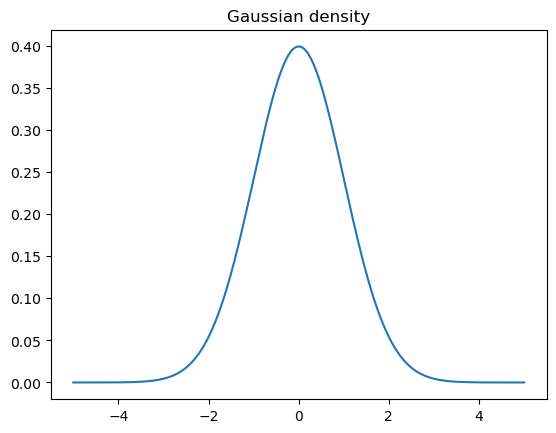

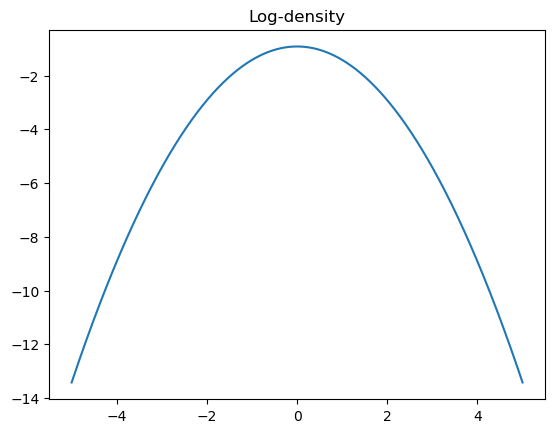

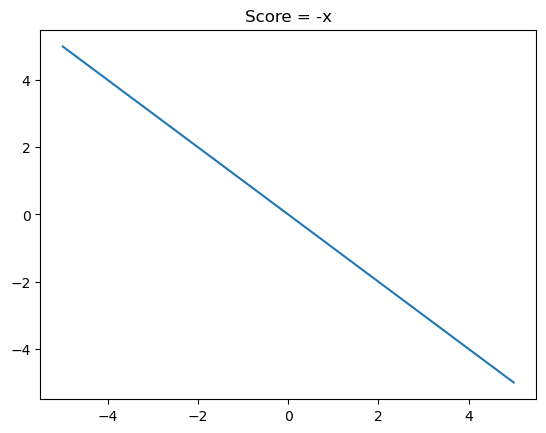

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5,5,1000)
p = 1/np.sqrt(2*np.pi)*np.exp(-x**2/2)
logp = np.log(p)
score = -x

plt.figure()
plt.plot(x, p)
plt.title("Gaussian density")
plt.show()

plt.figure()
plt.plot(x, logp)
plt.title("Log-density")
plt.show()

plt.figure()
plt.plot(x, score)
plt.title("Score = -x")
plt.show()


#### Visualizing the Score: Why It Pulls Toward the Mean

The three graphs above illustrate the relationship between a probability distribution and its score function:

1. **Gaussian Density Plot:**  
    Shows the familiar bell curve of a normal distribution, centered at the mean ($\mu=0$).

2. **Log-Density Plot:**  
    The log-density is a downward-opening parabola, peaking at the mean. Its slope at any point indicates how quickly probability decreases as you move away from the mean.

3. **Score Function Plot ($s(x) = -x$):**  
    The score is the derivative of the log-density. For a standard normal, $s(x) = -x$.  
    - For $x > 0$, the score is negative, pointing left (back toward the mean).
    - For $x < 0$, the score is positive, pointing right (again toward the mean).
    - The farther $x$ is from the mean, the larger the magnitude of the score, so the "pull" is stronger.

**Conclusion:**  
The score always points in the direction of higher probability—toward the mean (expected value) of the distribution. This is why, in diffusion models, following the score field denoises samples by pulling them back toward the most typical (expected) region.


For $\mathcal N(\mu,\sigma^2)$:

$$
s(x) = -\frac{x-\mu}{\sigma^2}
$$

So the score always pulls toward the mean.



### Example 2: Bimodal Normal Distribution


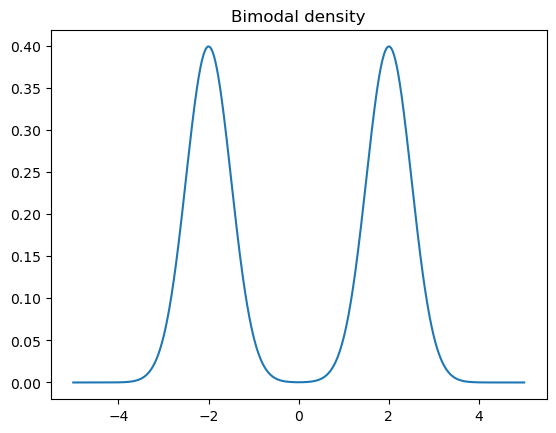

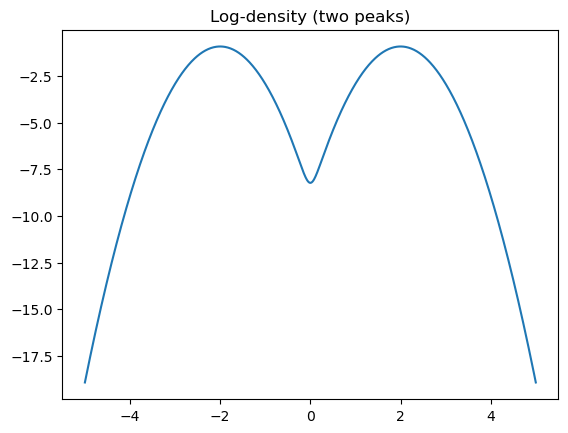

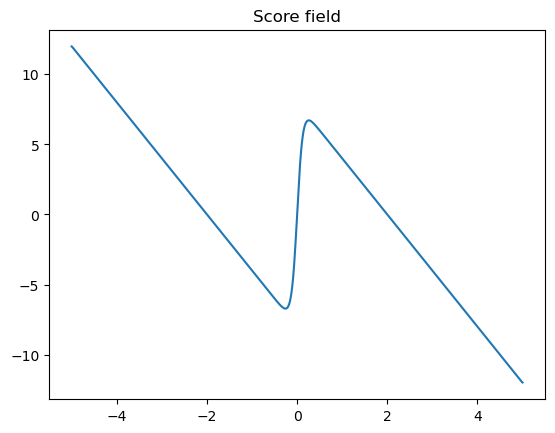

In [14]:

mu1, mu2 = -2, 2
sigma = 0.5

def gaussian(x, mu):
    return 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-(x-mu)**2/(2*sigma**2))

p_mix = 0.5*gaussian(x, mu1) + 0.5*gaussian(x, mu2)
logp_mix = np.log(p_mix)
score_mix = np.gradient(logp_mix, x)

plt.figure()
plt.plot(x, p_mix)
plt.title("Bimodal density")
plt.show()

plt.figure()
plt.plot(x, logp_mix)
plt.title("Log-density (two peaks)")
plt.show()

plt.figure()
plt.plot(x, score_mix)
plt.title("Score field")
plt.show()



### Deriving the score for the bimodal mixture

Let

$$
p(x)=\frac{1}{2}p_1(x)+\frac{1}{2}p_2(x),
\qquad
p_k(x)=\mathcal N(x;\mu_k,\sigma^2).
$$

The score is:

$$
s(x)=\frac{d}{dx}\log p(x)=\frac{p'(x)}{p(x)}.
$$

Compute $p'(x)$:

$$
p'(x)=\frac{1}{2}p_1'(x)+\frac{1}{2}p_2'(x).
$$

For each Gaussian component,

$$
\frac{d}{dx}\log p_k(x) = -\frac{x-\mu_k}{\sigma^2}
\quad\Longrightarrow\quad
p_k'(x)=p_k(x)\left(-\frac{x-\mu_k}{\sigma^2}\right).
$$

So:

$$
p'(x)=\frac{1}{2}p_1(x)\left(-\frac{x-\mu_1}{\sigma^2}\right)
+\frac{1}{2}p_2(x)\left(-\frac{x-\mu_2}{\sigma^2}\right).
$$

Divide by $p(x)$:

$$
s(x)
=
\frac{
\frac{1}{2}p_1(x)\left(-\frac{x-\mu_1}{\sigma^2}\right)
+\frac{1}{2}p_2(x)\left(-\frac{x-\mu_2}{\sigma^2}\right)
}{
\frac{1}{2}p_1(x)+\frac{1}{2}p_2(x)
}.
$$

Define responsibilities

$$
r_k(x)=\frac{p_k(x)}{p_1(x)+p_2(x)}.
$$

Then the score becomes a weighted average:

$$
\boxed{
s(x)=r_1(x)\left(-\frac{x-\mu_1}{\sigma^2}\right)+r_2(x)\left(-\frac{x-\mu_2}{\sigma^2}\right)
}.
$$

### Explanation

- Near $\mu_1$, $p_1(x)\gg p_2(x)$ so $r_1(x)\approx 1$ and the score behaves like the left Gaussian’s score (pull toward $\mu_1$).
- Near $\mu_2$, $r_2(x)\approx 1$ and it pulls toward $\mu_2$.
- Between modes, the score is a compromise weighted by how plausible each mode is at that $x$.

This is why the score field points toward the nearest (most plausible) peak.



The score always points toward the nearest mode.



## Review: Forward Diffusion

Closed-form noising:

$$
x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad \varepsilon \sim \mathcal N(0,1).
$$

The network is trained to predict:

$$
\varepsilon_\theta(x_t,t) \approx \varepsilon.
$$



### Key Result: Noise Prediction Equals Score

It turns out that the noise prediction in DDMP is closely related to the concept of the score. 

Denoising-score identity:

$$
\nabla_{x_t}\log p_t(x_t)
=
-\frac{1}{\sqrt{1-\bar\alpha_t}}
\mathbb{E}[\varepsilon \mid x_t].
$$

Since the network estimates this expectation:

$$
s_t(x_t)
\approx
-\frac{1}{\sqrt{1-\bar\alpha_t}}
\varepsilon_\theta(x_t,t).
$$

So the network is really learning the **score field**.



### Derivation of the denoising-score identity (1D, DDPM notation)

We start from the forward *marginal* corruption model at time $t$:

$$
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad \varepsilon\sim \mathcal N(0,1).
$$

Define

$$
\sigma_t = \sqrt{1-\bar\alpha_t}.
$$

Then the conditional density is a Gaussian:

$$
q(x_t\mid x_0)=\mathcal N\!\left(x_t;\sqrt{\bar\alpha_t}\,x_0,\sigma_t^2\right).
$$

The (unknown) marginal density of $x_t$ under the data distribution is:

$$
p_t(x_t)=\int p_0(x_0)\,q(x_t\mid x_0)\,dx_0.
$$

Differentiating $p_t(x_t)$ under the integral

$$
\frac{d}{dx_t}p_t(x_t)=\int p_0(x_0)\,\frac{d}{dx_t}q(x_t\mid x_0)\,dx_0.
$$

For a Gaussian in $x_t$,

$$
\frac{d}{dx_t}\log q(x_t\mid x_0)= -\frac{x_t-\sqrt{\bar\alpha_t}x_0}{\sigma_t^2},
$$

so

$$
\frac{d}{dx_t}q(x_t\mid x_0)
=
-\frac{x_t-\sqrt{\bar\alpha_t}x_0}{\sigma_t^2}\,q(x_t\mid x_0).
$$

Therefore,

$$
\frac{d}{dx_t}p_t(x_t)
=
-\frac{1}{\sigma_t^2}
\int (x_t-\sqrt{\bar\alpha_t}x_0)\,p_0(x_0)\,q(x_t\mid x_0)\,dx_0.
$$

Dividing by $p_t(x_t)$ and recognizing a posterior expectation

The score is

$$
s_t(x_t)=\frac{d}{dx_t}\log p_t(x_t)=\frac{\frac{d}{dx_t}p_t(x_t)}{p_t(x_t)}.
$$

Define the posterior over $x_0$ given $x_t$ (Bayes rule):

$$
p(x_0\mid x_t)=\frac{p_0(x_0)\,q(x_t\mid x_0)}{p_t(x_t)}.
$$

So:

$$
s_t(x_t)
=
-\frac{1}{\sigma_t^2}
\int (x_t-\sqrt{\bar\alpha_t}x_0)\,p(x_0\mid x_t)\,dx_0
=
-\frac{1}{\sigma_t^2}\,\mathbb E\!\left[x_t-\sqrt{\bar\alpha_t}x_0\mid x_t\right].
$$

Rearrange:

$$
s_t(x_t)
=
\frac{1}{\sigma_t^2}\left(\sqrt{\bar\alpha_t}\,\mathbb E[x_0\mid x_t]-x_t\right).
$$

This is one standard form of the denoising-score identity. 

This equation can be converted  into the noise form

From the forward equation,

$$
x_t-\sqrt{\bar\alpha_t}x_0 = \sigma_t\,\varepsilon.
$$

Condition on $x_t$ and take expectations:

$$
\mathbb E[x_t-\sqrt{\bar\alpha_t}x_0\mid x_t]
=
\sigma_t\,\mathbb E[\varepsilon\mid x_t].
$$

Plug into the earlier expression:

$$
s_t(x_t)
=
-\frac{1}{\sigma_t^2}\,\sigma_t\,\mathbb E[\varepsilon\mid x_t]
=
-\frac{1}{\sigma_t}\,\mathbb E[\varepsilon\mid x_t].
$$

Finally substitute $\sigma_t=\sqrt{1-\bar\alpha_t}$:

$$
\boxed{
\nabla_{x_t}\log p_t(x_t)
=
-\frac{1}{\sqrt{1-\bar\alpha_t}}\,
\mathbb E[\varepsilon\mid x_t]
}.
$$

Since the neural network training objective makes the network approximate:

$$
\varepsilon_\theta(x_t,t)\approx \mathbb E[\varepsilon\mid x_t],
$$

so:

$$
\boxed{
s_t(x_t)
\approx
-\frac{1}{\sqrt{1-\bar\alpha_t}}\,
\varepsilon_\theta(x_t,t)
}.
$$

**Key Observation** The network’s noise prediction is (up to a known scale factor) a direct estimate of the score field.



## Reverse Diffusion = Score Step + Noise

Reverse update can now be written directly in score form:

$$
x_{t-1}
=
x_t
+
\beta_t\, s_t(x_t)
+
\sqrt{\beta_t}\,z,
\qquad z\sim \mathcal N(0,1).
$$

Substitute the score expression:

$$
\boxed{
x_{t-1}
=
x_t
-
\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}
\varepsilon_\theta(x_t,t)
+
\sqrt{\beta_t}\,z.
}
$$



###  Side-by-side: score-form update vs. the original DDPM reverse sampling step

#### Score-form (error-form) 

We wrote the reverse step as:

$$
x_{t-1}
=
x_t
-
\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}
\varepsilon_\theta(x_t,t)
+
\sqrt{\beta_t}\,z,
\qquad z\sim\mathcal N(0,1).
$$

This is the clean “**subtract predicted noise + add calibrated noise**” picture.

#### Original DDPM reverse sampling step (Ho et al. style, still in $\varepsilon_\theta$ form)

The commonly stated DDPM sampling step is:

$$
x_{t-1}
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}
\varepsilon_\theta(x_t,t)
\right)
+
\sqrt{\tilde\beta_t}\,z,
\qquad z\sim\mathcal N(0,1),
$$

where the “posterior variance” is

$$
\tilde\beta_t
=
\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\,\beta_t.
$$

#### Why are these two conceptually equivalent

Both equations have the same two conceptual ingredients:

1. **Denoising drift (deterministic part)**  
   Both subtract the predicted noise direction
   $$
   -\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\varepsilon_\theta(x_t,t),
   $$
   which is exactly the score step written in error form.

2. **Sampling randomness (stochastic part)**  
   Both add fresh Gaussian noise $z\sim\mathcal N(0,1)$ with a schedule-dependent scale.

So the “mechanism” is identical:
> take a small denoising step guided by $\varepsilon_\theta$, then inject Gaussian randomness to keep sampling diversity.

#### Subtle differences (what we simplified in the score-form)

The score-form update above is a **simplified / schematic** version of the original DDPM step.

**Difference 1: the $1/\sqrt{\alpha_t}$ scaling**

Original DDPM uses

$$
\frac{1}{\sqrt{\alpha_t}}
$$

multiplying the whole mean. Since $\alpha_t=1-\beta_t$ and $\beta_t$ is small in typical schedules:

$$
\frac{1}{\sqrt{\alpha_t}} = \frac{1}{\sqrt{1-\beta_t}} \approx 1 + \frac{1}{2}\beta_t.
$$

So it is a mild rescaling, often close to 1.

**Difference 2: noise variance is $\tilde\beta_t$ (not exactly $\beta_t$)**

Original DDPM adds noise with variance $\tilde\beta_t$, not $\beta_t$:

$$
\sqrt{\tilde\beta_t}\,z
\quad \text{vs.} \quad
\sqrt{\beta_t}\,z.
$$

But note:

$$
\tilde\beta_t
=
\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\,\beta_t
\approx \beta_t
$$

because $1-\bar\alpha_t$ and $1-\bar\alpha_{t-1}$ are very close for small steps.

**Bottom line:** our score-form update keeps the **core intuition** (subtract predicted noise + add Gaussian noise) while dropping two schedule-specific refinements:
- the mild $1/\sqrt{\alpha_t}$ scaling, and
- the slightly adjusted variance $\tilde\beta_t$.



### Why the reverse update has this form?

At time $t$, the random variable $x_t$ is distributed according to a density $p_t(x)$.
The score

$$
s_t(x)=\nabla_x\log p_t(x)
$$

is the local direction in which $\log p_t(x)$ increases the fastest.

So if we could follow the score field deterministically, a generic “uphill” step would look like:

$$
x \leftarrow x + \eta\, s_t(x).
$$

In diffusion sampling we do something extremely similar, but with two important details:

1. the step size is tied to the schedule ($\eta=\beta_t$ in this schematic view), and  
2. we add **calibrated noise** so we sample from the full distribution rather than collapsing to a mode.

#### A) Deterministic term: $\beta_t\,s_t(x_t)$

Consider a tiny step:

$$
x_{t-1}^{\text{det}} = x_t + \beta_t\,s_t(x_t).
$$

Why does this “denoise”?

- In the forward process, noise gradually spreads probability mass out.
- The reverse process must push mass back toward regions of higher probability under $p_t$.
- The score points exactly toward higher $\log p_t(x)$, i.e., toward “more typical” samples at that noise level.

For a Gaussian, the score literally points back toward the mean.
For a mixture, it points toward the nearest (most plausible) mode.

So $\beta_t\,s_t(x_t)$ is the **denoising drift**.


#### B) Stochastic term: $\sqrt{\beta_t}\,z$

If we only did the deterministic step, the chain would behave like gradient ascent on $\log p_t$ and would tend to collapse toward peaks (mode-seeking).

But diffusion models are meant to **sample**, not just find the single most likely point.

So we add Gaussian noise:

$$
\sqrt{\beta_t}\,z,
\qquad z\sim\mathcal N(0,1).
$$

Why the scale $\sqrt{\beta_t}$?

- In the forward process, each step adds Gaussian noise with variance $\beta_t$.
- The reverse process must keep the correct amount of randomness at each step to match the target distribution.
- The schedule-controlled variance ensures we do not “over-randomize” late in the chain and do not “under-randomize” early in the chain.

So this term is the **sampling randomness**.

#### C) Putting them together: “drift + diffusion”

The compact update:

$$
x_{t-1}
=
x_t
+
\beta_t\, s_t(x_t)
+
\sqrt{\beta_t}\,z
$$

should be read as:

- **drift** along the score field (denoise), plus
- **diffusion** noise (keep diversity).

This is why people say: “reverse diffusion is following the score field plus calibrated noise.”

#### Substituting the learned score (error form)

From the denoising-score identity:

$$
s_t(x_t)
\approx
-\frac{1}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t),
$$

so the reverse update becomes:

$$
x_{t-1}
=
x_t
-
\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}
\varepsilon_\theta(x_t,t)
+
\sqrt{\beta_t}\,z.
$$

The network predicts the noise; we **subtract** an appropriate **fraction of that noise**, then **add back** schedule-controlled **randomness**.


## Example: 1D Reverse Simulation (Score + Noise Only)


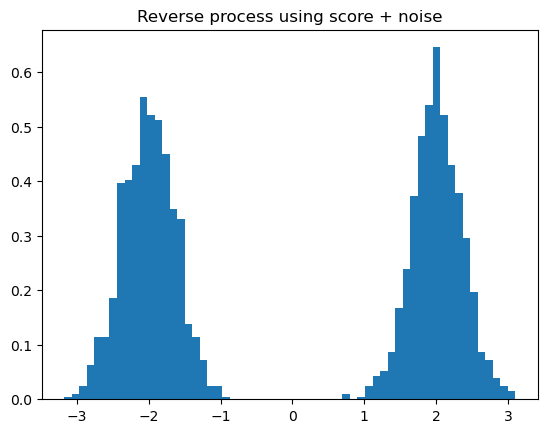

In [15]:

np.random.seed(0)

# Start from wide Gaussian noise
samples = np.random.normal(0,3,2000)

beta = 0.05

for _ in range(40):
    # compute score numerically for bimodal
    s_vals = np.interp(samples, x, score_mix)
    noise = np.random.normal(0, np.sqrt(beta), size=len(samples))
    samples = samples + beta*s_vals + noise

plt.figure()
plt.hist(samples, bins=60, density=True)
plt.title("Reverse process using score + noise")
plt.show()



## Full MNIST Example (Score / Noise-Prediction Diffusion)

This section shows a complete diffusion model on MNIST using the **score approach**.

Key points:

- We train a neural network to predict the forward noise $\varepsilon$:
  $$
  \varepsilon_\theta(x_t,t)\approx \varepsilon.
  $$
- That prediction gives a score estimate:
  $$
  s_t(x_t)\approx -\frac{1}{\sqrt{1-\bar\alpha_t}}\varepsilon_\theta(x_t,t).
  $$
- Sampling is “subtract predicted noise + add calibrated Gaussian noise” over timesteps.

In [5]:

# If needed, uncomment the next line in a fresh environment:
# !pip -q install torch torchvision

import sys, subprocess, importlib.util, os
import math
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
# Verify imports
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def ensure(pkg):
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Minimal deps
ensure("torch")
ensure("torchvision")

# Trigger MNIST download to ./data
from torchvision import datasets, transforms

os.makedirs("./data", exist_ok=True)
_ = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
_ = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

print("MNIST is available under ./data")

torch: 2.5.1
torchvision: 0.20.1
Device: cpu
MNIST is available under ./data


### Create the TinyUNet Model with Time Embeddings

In [6]:

# --- Time embedding (sinusoidal) ---
def sinusoidal_time_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    # timesteps: (B,) int64 or float
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(0, half, device=timesteps.device).float() / (half - 1)
    )
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb  # (B, dim)

# --- A tiny UNet-ish model for MNIST (28x28, 1 channel) ---
class TinyUNet(nn.Module):
    def __init__(self, time_dim=64, base=64):
        super().__init__()
        self.time_dim = time_dim
        
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, base*4),
            nn.SiLU(),
            nn.Linear(base*4, base*4),
        )
        
        # Down
        self.conv1 = nn.Conv2d(1, base, 3, padding=1)
        self.conv2 = nn.Conv2d(base, base, 3, padding=1)
        self.down = nn.Conv2d(base, base*2, 4, stride=2, padding=1)  # 28->14
        
        self.conv3 = nn.Conv2d(base*2, base*2, 3, padding=1)
        self.conv4 = nn.Conv2d(base*2, base*2, 3, padding=1)
        self.down2 = nn.Conv2d(base*2, base*4, 4, stride=2, padding=1)  # 14->7
        
        # Bottleneck
        self.mid1 = nn.Conv2d(base*4, base*4, 3, padding=1)
        self.mid2 = nn.Conv2d(base*4, base*4, 3, padding=1)
        
        # Up
        self.up1 = nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1)  # 7->14
        self.upc1 = nn.Conv2d(base*4, base*2, 3, padding=1)  # concat skip
        self.upc2 = nn.Conv2d(base*2, base*2, 3, padding=1)
        
        self.up2 = nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1)  # 14->28
        self.upc3 = nn.Conv2d(base*2, base, 3, padding=1)
        self.upc4 = nn.Conv2d(base, base, 3, padding=1)
        
        self.out = nn.Conv2d(base, 1, 1)
        
        # Inject time via FiLM-like bias
        self.to_bias1 = nn.Linear(base*4, base)
        self.to_bias2 = nn.Linear(base*4, base*2)
        self.to_bias3 = nn.Linear(base*4, base*4)
    
    def forward(self, x, t):
        # t: (B,) int64
        temb = sinusoidal_time_embedding(t, self.time_dim)
        temb = self.time_mlp(temb)  # (B, base*4)
        
        b1 = self.to_bias1(temb).unsqueeze(-1).unsqueeze(-1)
        b2 = self.to_bias2(temb).unsqueeze(-1).unsqueeze(-1)
        b3 = self.to_bias3(temb).unsqueeze(-1).unsqueeze(-1)
        
        # Down 1
        h1 = F.silu(self.conv1(x) + b1)
        h1 = F.silu(self.conv2(h1) + b1)
        d1 = self.down(h1)
        
        # Down 2
        h2 = F.silu(self.conv3(d1) + b2)
        h2 = F.silu(self.conv4(h2) + b2)
        d2 = self.down2(h2)
        
        # Mid
        m = F.silu(self.mid1(d2) + b3)
        m = F.silu(self.mid2(m) + b3)
        
        # Up 1
        u1 = self.up1(m)
        u1 = torch.cat([u1, h2], dim=1)
        u1 = F.silu(self.upc1(u1) + b2)
        u1 = F.silu(self.upc2(u1) + b2)
        
        # Up 2
        u2 = self.up2(u1)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = F.silu(self.upc3(u2) + b1)
        u2 = F.silu(self.upc4(u2) + b1)
        
        return self.out(u2)

model = TinyUNet(time_dim=64, base=64).to(device)
print("Parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")

Parameters: 3.575169 M


### Injecting Time Using FiLM-Style Bias

##### Code

    # Inject time via FiLM-like bias
    self.to_bias1 = nn.Linear(base*4, base)
    self.to_bias2 = nn.Linear(base*4, base*2)
    self.to_bias3 = nn.Linear(base*4, base*4)

##### What Problem Is This Solving?

In diffusion models, the neural network must depend on **time step** $t$:

$$
\varepsilon_\theta(x_t, t)
$$

The network must behave differently at early timesteps (very noisy inputs) and late timesteps (almost clean images).

Therefore, we need a way to **inject timestep information into intermediate feature maps**.


##### What Is Being Injected?

Typically, we first create a time embedding:

$$
e_t \in \mathbb{R}^{d}
$$

where in this case:

$$
d = 4 \cdot \text{base}
$$

So the time embedding dimension is `base*4`.

This embedding encodes the timestep $t$ using sinusoidal or learned embeddings.

#### What Does Each Linear Layer Do?

Each line:

    self.to_biasK = nn.Linear(base*4, output_dim)

implements a mapping:

$$
b_k(t) = W_k e_t + c_k
$$

where:

- $e_t \in \mathbb{R}^{4 \cdot \text{base}}$
- $b_k(t)$ matches the feature dimension at layer $k$

##### First Layer

$$
b_1(t) \in \mathbb{R}^{\text{base}}
$$

##### Second Layer

$$
b_2(t) \in \mathbb{R}^{2\cdot\text{base}}
$$

##### Third Layer

$$
b_3(t) \in \mathbb{R}^{4\cdot\text{base}}
$$

Each bias matches the channel dimension of the corresponding convolutional block.

#### Why Is This Called "FiLM-Like"?

FiLM (Feature-wise Linear Modulation) modifies activations as:

$$
\text{FiLM}(h) = \gamma(t) \odot h + \beta(t)
$$

where:

- $\gamma(t)$ = learned scale from conditioning
- $\beta(t)$ = learned bias from conditioning
- $\odot$ = elementwise multiplication

Here, we are implementing a simplified version:

$$
h' = h + b_k(t)
$$

That is:

- No scaling
- Only additive modulation

So this is a **bias-only FiLM layer**.

####  How It Is Used in Forward Pass

Suppose a feature map is:

$$
h_k \in \mathbb{R}^{B \times C_k \times H \times W}
$$

We compute:

$$
b_k(t) \in \mathbb{R}^{C_k}
$$

Then reshape and broadcast:

$$
h_k' = h_k + b_k(t)
$$

This shifts every spatial location equally but per-channel.

#### Why This Works for Diffusion

At different timesteps:

- Early $t$ → inputs are mostly noise
- Late $t$ → inputs are almost clean

The model must change its behavior smoothly with $t$.

By adding:

$$
b_k(t)
$$

the network learns:

- Different internal feature biases for different noise levels
- A time-dependent processing pipeline

Thus the model effectively learns:

$$
f_\theta(x_t, t)
$$

instead of just:

$$
f_\theta(x_t)
$$

####  Why Different Output Sizes?

Each convolution block has different channel width:

- First block → `base`
- Second block → `2*base`
- Third block → `4*base`

So we must project the same time embedding into different channel sizes.

Each layer learns its own time-dependent bias.

## Important point to note

The original convolution bias $b$:

- is constant across all timesteps.

The time bias $b_t$:

- changes for every timestep.
- is computed dynamically during the forward pass.

So the effective bias becomes:

$$
b_{\text{effective}} = b + b_t
$$

More advanced models use full FiLM:

$$
h' = \gamma(t) \odot h + \beta(t)
$$

which allows both scaling and shifting.

But bias-only modulation already works remarkably well.

## Summary

These lines implement:

$$
\text{Time Embedding} \rightarrow \text{Per-layer Bias}
$$

which allows the network to:

- Know how noisy the input is
- Adjust its denoising behavior accordingly
- Learn different score fields at different timesteps

Without time injection, diffusion models would fail.

Diffusion models are not just image-to-image networks.

They are:

> A family of networks indexed by time.

These linear layers allow the model to smoothly transition between them.

### Simple Example: One Convolution Filter + Time Bias Injection

We work through a fully concrete numeric example showing:

1. One convolution filter applied to an image  
2. The normal convolution bias  
3. The additional time-dependent bias  
4. The final output  

#### Input Image

Suppose we have a small 3×3 grayscale image:

$$
x =
\begin{bmatrix}
1 & 2 & 0 \\
0 & 1 & 3 \\
2 & 1 & 0
\end{bmatrix}
$$

#### Apply One Convolution Filter

Assume one 3×3 convolution filter:

$$
W =
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
$$

and a base convolution bias:

$b = 0.5$

#### Convolution Output (Single Pixel Example)

Since the filter is 3×3 and the image is 3×3 (no padding), the output is one scalar:

Compute elementwise multiply + sum:

$$
(1)(1) + (2)(0) + (0)(-1) \\
+ (0)(1) + (1)(0) + (3)(-1) \\
+ (2)(1) + (1)(0) + (0)(-1)
$$

Compute:

$$
1 + 0 + 0 + 0 + 0 - 3 + 2 + 0 + 0
=
0
$$

Add convolution bias:

$$
g = 0 + 0.5 = 0.5
$$

So before time injection:

$$
g = 0.5
$$

#### Time Embedding Produces Time Bias

Suppose after time embedding and linear projection we get:

$$b_t = -0.8$$

This is the per-channel time bias for this single filter.

#### Add Time Bias

The final feature before activation is:

$$
h = g + b_t
$$

$$
h = 0.5 + (-0.8) = -0.3
$$

#### Apply Activation (SiLU)

$$
\text{SiLU}(z) = z \cdot \sigma(z)
$$

$$
\sigma(-0.3) \approx 0.425
$$

So:

$$
\text{SiLU}(-0.3) \approx -0.3 \times 0.425 = -0.1275
$$

#### Comparing with and without time

Without time:

$$
\text{output} \approx \text{SiLU}(0.5) \approx 0.311
$$

With time bias:

$$
\text{output} \approx -0.1275
$$

The **same filter and same input** produced completely different behavior depending on time.

#### Generally

For channel $c$:

Convolution output:

$$
g_{c,i,j} = (W_c * x)_{i,j} + b_c
$$

Time injection:

$$
h_{c,i,j} = g_{c,i,j} + b_{t,c}
$$

Final:

$$
h_{c,i,j} = (W_c * x)_{i,j} + b_c + b_{t,c}
$$

Each channel has:

- A learned static bias $b_c$
- A learned time-dependent bias $b_{t,c}$

So the effective bias is:

$$
b_c^{\text{effective}}(t) = b_c + b_{t,c}
$$

Time simply shifts the channel response up or down.

### Create the DDPM Schedule and q_sample

In [7]:

# --- DDPM schedule ---
T = 200  # keep small for faster demo; typical papers use 1000
beta_start, beta_end = 1e-4, 0.02
betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

# Helper to extract the appropriate alpha_bar for a batch of indices
def extract(a, t, x_shape):
    # a: (T,), t: (B,)
    # gather the appropriate alpha_bar for each sample in the batch
    # the gather function is used to index the tensor 'a' at the positions specified by 't'
    out = a.gather(0, t)
    # return the gathered values reshaped to (B, 1, 1, 1) for broadcasting with the input images
    return out.view(-1, *([1]*(len(x_shape)-1)))

# Forward: x_t = sqrt(abar_t)*x0 + sqrt(1-abar_t)*eps
def q_sample(x0, t, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    sqrt_abar = extract(torch.sqrt(alphas_bar), t, x0.shape)
    sqrt_one_minus = extract(torch.sqrt(1.0 - alphas_bar), t, x0.shape)
    return sqrt_abar * x0 + sqrt_one_minus * eps, eps


In [9]:
# Just to make sure that MNIST has been loaded correctly
# --- Smoke test: load one batch ---
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tfm_smoke = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds_smoke = datasets.MNIST(root="./data", train=True, download=True, transform=tfm_smoke)
# load a batch of size 8 to check everything works
train_loader_smoke = DataLoader(train_ds_smoke, batch_size=8, shuffle=True)

x0_smoke, y_smoke = next(iter(train_loader_smoke))
print("Batch shape:", x0_smoke.shape, "Labels:", y_smoke.tolist())

Batch shape: torch.Size([8, 1, 28, 28]) Labels: [9, 3, 2, 1, 0, 5, 6, 4]


### Forward Diffusion Sampling `q_sample` — Code ↔ Math (Line-by-Line)

We want to sample from the *closed-form* forward marginal:

$$
q(x_t \mid x_0) = \mathcal{N}\!\left(x_t;\sqrt{\bar{\alpha}_t}\,x_0,\,(1-\bar{\alpha}_t)I\right)
$$

Equivalently, using the reparameterization with standard Gaussian noise:

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon,
\qquad
\varepsilon \sim \mathcal{N}(0,I)
$$

Below is the code and what each line means.

##### Function header

**Code**

    def q_sample(x0, t, eps=None):

**Math**

Inputs represent:

- $x_0$: clean data sample
- $t$: timestep index (may be a batch of timesteps)
- $\varepsilon$: optional noise (if not provided, sample fresh noise)

#### Sample noise if not provided

**Code**

    if eps is None:
        eps = torch.randn_like(x0)

**Math**

If no noise is supplied, draw:

$$
\varepsilon \sim \mathcal{N}(0, I)
$$

where $\varepsilon$ has the same shape as $x_0$.

#### Compute $\sqrt{\bar{\alpha}_t}$ for each sample in the batch

**Code**

    sqrt_abar = extract(torch.sqrt(alphas_bar), t, x0.shape)

**Math**

This selects the scalar value $\sqrt{\bar{\alpha}_t}$ corresponding to each timestep in the batch and broadcasts it to match the tensor shape:

$$
\sqrt{\bar{\alpha}_t}
\quad \text{(broadcast to shape of } x_0 \text{)}
$$

Here:

$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s,
\qquad
\alpha_s = 1-\beta_s
$$

##### Compute $\sqrt{1-\bar{\alpha}_t}$ for each sample

**Code**

    sqrt_one_minus = extract(torch.sqrt(1.0 - alphas_bar), t, x0.shape)

**Math**

This selects and broadcasts:

$$
\sqrt{1-\bar{\alpha}_t}
\quad \text{(broadcast to shape of } x_0 \text{)}
$$

#### Construct $x_t$ using the closed-form forward marginal

**Code**

    return sqrt_abar * x0 + sqrt_one_minus * eps, eps

**Math**

This implements exactly:

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon
$$

and returns both:

- $x_t$ (the noised sample)
- $\varepsilon$ (the exact noise used)

So the function outputs:

$$
(x_t,\varepsilon)
$$

#### Summary

This function samples from the forward diffusion marginal:

$$
q(x_t \mid x_0)
=
\mathcal{N}\!\left(\sqrt{\bar{\alpha}_t}x_0,\,(1-\bar{\alpha}_t)I\right)
$$

using the reparameterization:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\varepsilon.
$$

In [ ]:

# --- Data ---
# transforms: ToTensor() converts PIL images to tensors in [0,1], Normalize((0.5,), (0.5,)) scales them to 
# [-1,1] which is better for diffusion stability

tfm = transforms.Compose([
    transforms.ToTensor(),              # [0,1]
    transforms.Normalize((0.5,), (0.5,))   # [-1,1] for diffusion stability
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, drop_last=True)

# --- Training ---
# Train the model to predict the noise added at each step of the diffusion process. 
# The loss is the MSE between the predicted noise and the actual noise.

opt = torch.optim.AdamW(model.parameters(), lr=2e-4)
epochs = 1  # increase to 5-20 for much better samples

model.train()
for ep in range(epochs):
    running = 0.0
    # this for loop iterates over the training data loader, providing batches of data (x0, _) where x0 
    # are the input images and _ are the labels (which we ignore for diffusion training)
    # i represents the batch index, and (x0, _) is the batch of images and labels from the DataLoader

    for i, (x0, _) in enumerate(train_loader):
        x0 = x0.to(device)
        
        # create a random t for each sample in the batch, which determines how much noise to add
        t = torch.randint(0, T, (x0.size(0),), device=device)
        
        # q_sample adds noise to x0 according to the diffusion process at time step t, returning 
        # the noisy image xt and the noise eps that was added
        xt, eps = q_sample(x0, t)
        
        # preduct the noise eps from the noisy image xt and time step t using the model; this is what the model is trained to do
        eps_pred = model(xt, t)

        # calculate the loss between actual and predicted error
        loss = F.mse_loss(eps_pred, eps)
        

        opt.zero_grad(set_to_none=True)
        # backpropagate the loss to compute gradients, and then update the model parameters using the optimizer
        loss.backward()
        opt.step()
        
        running += loss.item()
        if (i+1) % 200 == 0:
            print(f"epoch {ep+1} step {i+1}: loss={running/200:.4f}")
            running = 0.0

print("Training done.")

epoch 1 step 200: loss=0.3545
epoch 1 step 400: loss=0.1438
Training done.


## Reverse DDPM Step — Code ↔ Math (VSCode-Safe)

### Noise Prediction

**Code**
    
    eps_pred = model(x, t)

**Math**

$$
\varepsilon_\theta(x_t, t)
$$

The network predicts the noise in

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon
$$

### Diffusion Schedule Parameters

**Code**

    beta_t = betas[ti]
    alpha_t = alphas[ti]
    abar_t = alphas_bar[ti]

**Math**

$$
\alpha_t = 1 - \beta_t
$$

$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s
$$

### Reverse Mean (Epsilon Parameterization)

**Code**

    coef = beta_t / torch.sqrt(1.0 - abar_t)
    mean = (x - coef * eps_pred) / torch.sqrt(alpha_t)

**Math**

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_\theta(x_t,t)
\right)
$$

This is the denoising drift term.

### Posterior Variance

**Code**

    abar_tm1 = alphas_bar[ti-1]
    tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t

**Math**

$$
\tilde{\beta}_t
=
\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}\,\beta_t
$$

### Sampling Step

**Code**

    noise = torch.randn_like(x)
    x = mean + torch.sqrt(tilde_beta) * noise

**Math**

$$
x_{t-1}
=
\mu_\theta(x_t,t)
+
\sqrt{\tilde{\beta}_t}\,z,
\qquad
z \sim \mathcal{N}(0,I)
$$

### Final Step (No Noise)

**Code**

    else:
        x = mean

**Math**

$$
x_0 = \mu_\theta(x_1,1)
$$

## Summary

Each reverse step performs:

$$
x_{t-1}
=
\text{denoise drift}
+
\text{calibrated Gaussian noise}
$$

This ensures the reverse chain matches the forward diffusion process.

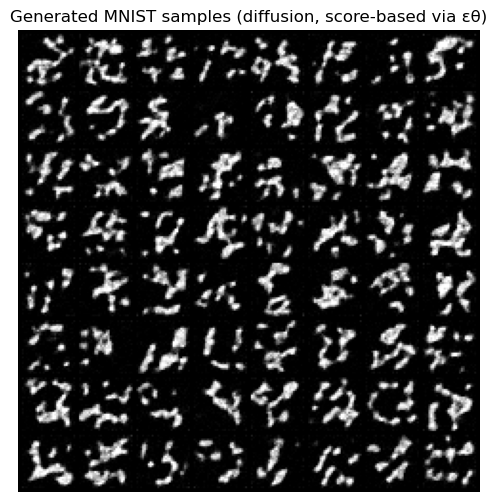

In [11]:

# --- Sampling (reverse diffusion) ---
@torch.no_grad()

# n is the number of samples to generate; it starts with random noise and iteratively denoises it using the model
def p_sample_loop(n=64):
   
    # model is a neural network that predicts noise (eps_pred) given noisy image (x) and time step (t)
    model.eval()

    # start with some random normal noise
    x = torch.randn(n, 1, 28, 28, device=device)  # x_T ~ N(0,1)
    
    for ti in reversed(range(T)):
        
        # create a tensor of time steps (ti) for the current iteration, which will be used as input to the model to predict the noise
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        
        # predict the  noise eps_pred from the noisy image x and time step t using the model; 
        # this is the reverse diffusion step where we try to denoise the image

        eps_pred = model(x, t)
        
        beta_t = betas[ti]
        alpha_t = alphas[ti]
        abar_t = alphas_bar[ti]
        
        # Original DDPM-style mean in epsilon form (kept here for correctness/stability)
        # x_{t-1} = 1/sqrt(alpha_t) * (x_t - beta_t/sqrt(1-abar_t) * eps_pred) + sigma_t * z
        coef = beta_t / torch.sqrt(1.0 - abar_t)
        mean = (x - coef * eps_pred) / torch.sqrt(alpha_t)
        
        if ti > 0:
            # Use posterior variance ~ beta_t (simple) or tilde_beta_t (more exact).
            # We'll use tilde_beta_t for better fidelity:
            abar_tm1 = alphas_bar[ti-1]
            tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(tilde_beta) * noise
        else:
            x = mean
    
    return x

samples = p_sample_loop(64)

# map back to [0,1] for visualization
samples_vis = (samples.clamp(-1,1) + 1) / 2
grid = utils.make_grid(samples_vis, nrow=8)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title("Generated MNIST samples (diffusion, score-based via εθ)")
plt.show()

## Guided Diffusion

### The Limitation of Unconditional Diffusion

A standard diffusion model learns the data distribution:

$$
p_\theta(x)
$$

It is trained to reverse the forward noise process:

$$
x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon
$$

and learns a score field (via noise prediction):

$$
\nabla_{x_t} \log p_t(x_t)
$$

During sampling, it produces samples from the learned data distribution:

$$
x_{t-1} = \mu_\theta(x_t, t) + \sqrt{\tilde{\beta}_t} z
$$

or equivalently (score form):

$$
x_{t-1}
=
x_t
+
\beta_t s_t(x_t)
+
\sqrt{\beta_t} z
$$

This works extremely well — but it samples from:

$$
p(x)
$$

not from:

$$
p(x \mid y)
$$

That is the core limitation.

### The Real Goal in Most Applications

In practice, we rarely want arbitrary samples from the data distribution.

We want **controlled generation**:

- A specific class
- A specific text description
- A specific style
- A specific semantic attribute
- A specific layout
- A specific pose
- A specific domain

Mathematically, we want:

$$
p(x \mid y)
$$

where $y$ could be:

- a class label
- a caption
- an embedding
- a style code
- a segmentation map
- an audio condition
- another image

Unconditional diffusion does not enforce this.

### Why Conditioning Is Hard in Diffusion

In autoregressive models, conditioning is straightforward:

$$
p(x \mid y) = \prod_i p(x_i \mid x_{<i}, y)
$$

You simply feed $y$ into the model.

In diffusion, generation happens through a **stochastic reverse process**.

The reverse dynamic is:

$$
dx = \text{score}(x,t)\,dt + \text{noise}
$$

So if we want conditional generation, we must modify the **score field itself**.

That is the key insight:

> Guided diffusion modifies the vector field that moves samples through space.

### The Geometric Interpretation

The score:

$$
s_t(x) = \nabla_x \log p_t(x)
$$

points toward regions of higher probability density.

Unconditional diffusion follows this vector field.

Guided diffusion modifies it:

$$
s_t^{\text{guided}}(x)
=
s_t(x)
+
\text{conditioning force}
$$

So instead of flowing toward “any plausible image,”
the sample flows toward “plausible images consistent with condition $y$.”

### Example 1 — Bimodal Simple Case (1D)

Suppose the data distribution is bimodal:

$$
p(x) = \frac{1}{2} \mathcal{N}(-2, \sigma^2)
+
\frac{1}{2} \mathcal{N}(+2, \sigma^2)
$$

Unconditional diffusion produces both modes equally.

But suppose we want:

- $y=0$ → left mode only
- $y=1$ → right mode only

Then we need to sample from:

$$
p(x \mid y=0)
=
\mathcal{N}(-2, \sigma^2)
$$

$$
p(x \mid y=1)
=
\mathcal{N}(+2, \sigma^2)
$$

Guided diffusion adds a force:

$$
\nabla_x \log p(y \mid x)
$$

that pushes samples toward the desired mode.

Without guidance, samples randomly land in both peaks.

With guidance, the vector field tilts toward the selected peak.

### Example 2 — Class-Conditional MNIST

Unconditional diffusion learns:

$$
p(x)
=
\text{distribution over digits 0–9}
$$

If we sample, we get random digits.

But suppose we want only digit “3”:

$$
p(x \mid y=3)
$$

Guided diffusion modifies the reverse drift so that:

- the model still produces valid MNIST images
- but the images are increasingly classified as 3

Without guidance → random digit  
With guidance → target digit

### Example 3 — Text-to-Image Generation

In text-to-image models, we want:

$$
p(x \mid \text{text})
$$

Example:

> “A red fox sitting in snow”

Unconditional diffusion might produce:

- fox
- snow
- forest
- random animal
- landscape

Guided diffusion modifies the score field using text embeddings so that:

- samples flow toward regions matching the caption
- semantic alignment increases
- irrelevant modes are suppressed

### Example 4 — Style Control

Suppose diffusion is trained on paintings of multiple artists.

Unconditional model samples:

$$
p(x)
$$

But we want:

$$
p(x \mid \text{Van Gogh style})
$$

Guidance steers generation toward that stylistic manifold.

Without guidance, style is random.
With guidance, style is controlled.

### Example 5 — Safety or Filtering

We may want:

$$
p(x \mid \text{safe})
$$

or

$$
p(x \mid \text{not containing violence})
$$

Guidance can reduce probability mass in unwanted regions.

This turns diffusion into a controllable generator.



## Two Main Ways to Guide Diffusion

### A. Classifier Guidance

Modify score:

$$
s_t^{\text{guided}}(x)
=
s_t(x)
+
w \nabla_x \log p_\phi(y \mid x,t)
$$

Interpretation:

- The diffusion score ensures realism.
- The classifier gradient ensures condition alignment.

### B. Classifier-Free Guidance (CFG)

Combine conditional and unconditional predictions:

$$
\varepsilon_{\text{cfg}}
=
(1+w)\varepsilon_\theta(x_t,t,y)
-
w\varepsilon_\theta(x_t,t,\varnothing)
$$

Interpretation:

- Amplifies what distinguishes conditional from unconditional predictions.
- No external classifier required.

### The Tradeoff

Increasing guidance strength $w$:

- improves condition alignment
- reduces diversity
- may introduce artifacts

So guided diffusion balances:

$$
\text{realism}
\quad vs \quad
\text{condition strength}
$$


### Summary

Unconditional diffusion learns:

$$
\nabla_x \log p_t(x)
$$

Guided diffusion modifies it to approximate:

$$
\nabla_x \log p_t(x \mid y)
$$

Since:

$$
\log p(x \mid y)
=
\log p(x)
+
\log p(y \mid x)
-
\log p(y)
$$

Taking gradients:

$$
\nabla_x \log p(x \mid y)
=
\nabla_x \log p(x)
+
\nabla_x \log p(y \mid x)
$$

That identity is the mathematical foundation of classifier guidance.

Unconditional diffusion answers:

> “What images are plausible?”

Guided diffusion answers:

> “What images are plausible **and match this condition**?”

It is not a new generative model.

It is a controlled modification of the score field.


## Step-by-step methodology to build guided diffusion (both approaches)

This is a practical checklist you can follow to build **guided diffusion** in two mainstream ways.

### Approach A — Classifier guidance (external classifier $p_\phi(y\mid x_t,t)$)

**Goal:** sample from $p(x\mid y)$ using an **unconditional** diffusion model plus an **auxiliary classifier**.

1. **Train (or reuse) an unconditional diffusion model**
   - Train $\varepsilon_\theta(x_t,t)$ on your dataset (no labels required).
   - You will use it at sampling time to get the unconditional direction field (equivalently, an estimate of the score).

2. **Construct noisy training inputs for the classifier**
   - For each labeled $(x_0,y)$, sample $t\sim \mathrm{Unif}\{1,\dots,T\}$ and noise $\varepsilon\sim\mathcal N(0,1)$.
   - Form $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\varepsilon$.

3. **Train the noisy classifier**
   - Train a classifier $p_\phi(y\mid x_t,t)$ (condition on $t$ explicitly, or provide a time embedding).
   - Loss: cross-entropy on $y$.

4. **Sampling with guidance**
   - During sampling, compute:
     $$
     \nabla_x \log p_\phi(y\mid x_t,t)
     $$
     by backprop through the classifier.
   - Use guided score:
     $$
     s_t^{\text{guided}}(x)=s_t(x)+w\,\nabla_x\log p_\phi(y\mid x,t),
     $$
     then take the reverse step (drift + noise).

5. **Tune guidance strength $w$**
   - Larger $w$ increases condition adherence but can reduce diversity and cause artifacts.
   - Often there is a “sweet spot” depending on classifier strength and schedule.

**Common challenges**
- The classifier must be accurate on *noisy* inputs $x_t$; a clean-image classifier usually fails.
- Sampling is slower because every step requires classifier backprop.

### Approach B — Classifier-free guidance (CFG)

**Goal:** sample from $p(x\mid y)$ using a **conditional** diffusion model that also learns an unconditional branch via label drop.

1. **Train a conditional diffusion model**
   - Train $\varepsilon_\theta(x_t,t,y)$ on labeled data.
   - With probability $p_{\text{drop}}$, replace $y$ with a special “null” condition $\varnothing$.
   - This makes the same network learn both:
     - conditional predictions $\varepsilon_\theta(\cdot,y)$
     - unconditional predictions $\varepsilon_\theta(\cdot,\varnothing)$

2. **Sampling with CFG**
   - At each step, evaluate the model twice:
     $$
     \varepsilon_{\text{cond}}=\varepsilon_\theta(x_t,t,y),
     \qquad
     \varepsilon_{\text{uncond}}=\varepsilon_\theta(x_t,t,\varnothing).
     $$
   - Combine:
     $$
     \varepsilon_{\text{cfg}}
     =
     (1+w)\varepsilon_{\text{cond}}-w\,\varepsilon_{\text{uncond}}.
     $$
   - Use $\varepsilon_{\text{cfg}}$ in the reverse update.

3. **Tune $w$ and $p_{\text{drop}}$**
   - Typical: $p_{\text{drop}}\in[0.05,0.2]$ and $w\in[1,8]$ depending on domain.
   - Higher $w$ increases adherence but may hurt diversity.

**Common challenges**
- Requires labels (or conditioning signals) at diffusion training time.
- You pay ~2× compute at sampling (two forward passes), but **no backprop** is needed.

### Pros/cons comparison

**Classifier guidance**
- **Pros:** retrofit guidance onto an existing unconditional model; flexible if you can define/train a classifier.
- **Cons:** must train a *noise-robust* classifier; sampling is slower (needs backprop each step); can be brittle if classifier is overconfident.

**Classifier-free guidance**
- **Pros:** no classifier needed; usually very strong guidance; sampling uses only forward passes; widely used in modern diffusion.
- **Cons:** requires conditional training; ~2× sampling compute; guidance strength trades off diversity vs adherence.

**Rule of thumb**
- If you already have labels/conditions and can train conditionally → CFG is usually the default.
- If you have an unconditional model you cannot retrain, but can train a noisy classifier → classifier guidance is a good retrofit.



## Guided Diffusion (1D Examples)

Guided diffusion modifies the **direction field** used in the reverse step.

Recall the score-form reverse step:

$$
x_{t-1}=x_t+\beta_t s_t(x_t)+\sqrt{\beta_t}z,
\qquad z\sim\mathcal N(0,1).
$$

Guidance replaces $s_t(x)$ by a **guided score** $s_t^{\text{guided}}(x)$ that adds a steering force toward what we want.



### Classifier Guided diffusion in 1D

Let the unconditional distribution be bimodal (modes at $-2$ and $+2$).

Define a “condition” $y\in\{0,1\}$:

- $y=0$: steer toward the left mode
- $y=1$: steer toward the right mode

Classifier guidance uses:

$$
s_t^{\text{guided}}(x)=s_t(x)+w\,\nabla_x \log p_\phi(y\mid x,t).
$$

**Intuition:** the unconditional score makes samples look like valid data at noise level $t$; the classifier gradient tilts that vector field toward the desired class.


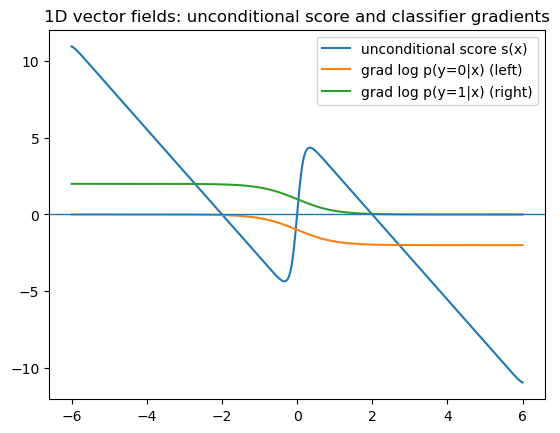

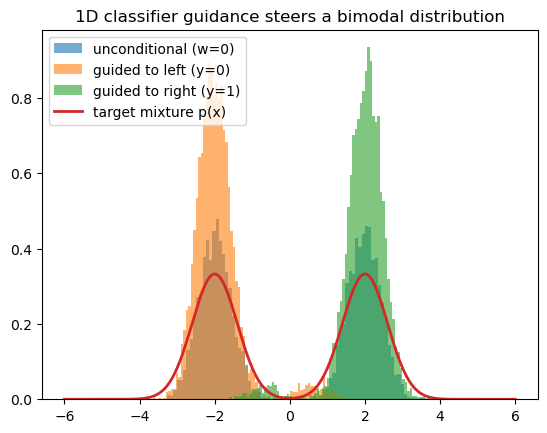

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

x_grid = np.linspace(-6,6,2000)
mu1, mu2 = -2, 2
sigma = 0.6

# the gaussian_1d function computes the value of a 1D Gaussian distribution with mean mu and standard deviation 
# sig at the points specified in x.

def gaussian_1d(x, mu, sig):
    return 1/(np.sqrt(2*np.pi)*sig) * np.exp(-(x-mu)**2/(2*sig**2))

p1 = gaussian_1d(x_grid, mu1, sigma)
p2 = gaussian_1d(x_grid, mu2, sigma)
p_mix = 0.5*p1 + 0.5*p2
logp = np.log(p_mix + 1e-12)
score_mix = np.gradient(logp, x_grid)

# simple classifier: p(y=1|x)=sigmoid(kx)
k = 2.0

# the sigmoid function is used to model the probability of class y=1 given x, where k controls 
# the steepness of the sigmoid curve; a larger k makes the transition between classes sharper around x=0

p_y1 = 1/(1+np.exp(-k*x_grid))

# the derivatives are needed because classifier guidance modifies the score by adding the gradient of the log-probability of the class;

grad_log_p_y1 = k*(1 - p_y1)   # d/dx log sigmoid(kx)
grad_log_p_y0 = -k*p_y1        # d/dx log (1-sigmoid(kx))

# Plot the unconditional score and the classifier gradients to visualize how they differ across the x-axis, 
# especially around the two modes of the distribution and the decision boundary of the classifier.

plt.figure()
plt.plot(x_grid, score_mix, label="unconditional score s(x)")
plt.plot(x_grid, grad_log_p_y0, label="grad log p(y=0|x) (left)")
plt.plot(x_grid, grad_log_p_y1, label="grad log p(y=1|x) (right)")
plt.axhline(0, linewidth=1)
plt.legend()
plt.title("1D vector fields: unconditional score and classifier gradients")
plt.show()

# n represents the number of samples to generate; it starts with random noise and iteratively denoises it using the model
# steps is the number of iterations to run the reverse diffusion process; more steps typically lead to better samples but take longer
# beta is the step size for the reverse diffusion; it controls how much we move in the direction of the score and classifier gradients at each step
# w is the weight for the classifier guidance; a higher w means stronger guidance towards the class specified by y

def guided_reverse_1d(n=5000, steps=80, beta=0.06, w=2.0, y=1):

    # s_interp and g_interp are interpolation functions that allow us to compute the score and classifier gradients 
    # at any point x during the reverse diffusion process, based on the precomputed values on the x_grid.

    s_interp = lambda xx: np.interp(xx, x_grid, score_mix)
    g_interp = lambda xx: np.interp(xx, x_grid, grad_log_p_y1 if y==1 else grad_log_p_y0)
    
    # x is initialized with random noise from a wide Gaussian distribution; this represents the starting point of the reverse diffusion process
    x = np.random.normal(0, 3, size=n)
    
    for _ in range(steps):
        # s is the score of the data distribution at the current points x, and 
        # g is the gradient of the log-probability of the class (from the classifier) at x;
        s = s_interp(x)
        g = g_interp(x)
        z = np.random.normal(0, 1, size=n)
        # the update step for x combines the score and classifier guidance, weighted by beta and w,
        # and adds noise scaled by sqrt(beta) to maintain stochasticity in the sampling process;
        x = x + beta*(s + w*g) + np.sqrt(beta)*z
    return x

samples_uncond = guided_reverse_1d(w=0.0, y=1)
samples_left   = guided_reverse_1d(w=2.5, y=0)
samples_right  = guided_reverse_1d(w=2.5, y=1)

plt.figure()
plt.hist(samples_uncond, bins=80, density=True, alpha=0.6, label="unconditional (w=0)")
plt.hist(samples_left,   bins=80, density=True, alpha=0.6, label="guided to left (y=0)")
plt.hist(samples_right,  bins=80, density=True, alpha=0.6, label="guided to right (y=1)")
plt.plot(x_grid, p_mix, linewidth=2, label="target mixture p(x)")
plt.legend()
plt.title("1D classifier guidance steers a bimodal distribution")
plt.show()


### Classifier-Free Guidance (CFG) in 1D Code ↔ Math Explanation

We explain each part of the following code and connect it directly to the mathematics of score-based diffusion and classifier-free guidance.

#### Gaussian Score Function

#### Code

    def score_gauss(x, mu, sig):
        return -(x-mu)/(sig**2)

#### Math

For a Gaussian:

$$
p(x) = \mathcal{N}(x;\mu,\sigma^2)
$$

The log-density is:

$$
\log p(x)
=
-\frac{(x-\mu)^2}{2\sigma^2}
+ C
$$

Taking the derivative:

$$
\nabla_x \log p(x)
=
-\frac{x-\mu}{\sigma^2}
$$

So this function implements the **score**:

$$
s(x) = \nabla_x \log p(x)
$$

Interpretation:

- If $x > \mu$, score is negative → pushes left.
- If $x < \mu$, score is positive → pushes right.
- It always points toward the Gaussian mean.

#### Initialize Noisy Samples

#### Code

    x = np.random.normal(0, 3, size=n)

#### Math

We start from noise:

$$
x_0 \sim \mathcal{N}(0, 3^2)
$$

This mimics diffusion sampling, which starts from a high-noise prior:

$$
x_T \sim \mathcal{N}(0, I)
$$


#### Unconditional Score (Mixture)

#### Code

    s_un = np.interp(x, x_grid, score_mix)

#### Math

This represents the unconditional score:

$$
s_{\text{un}}(x) = \nabla_x \log p(x)
$$

where

$$
p(x)
=
\frac{1}{2}\mathcal{N}(\mu_1,\sigma^2)
+
\frac{1}{2}\mathcal{N}(\mu_2,\sigma^2)
$$

This score field pushes samples toward *either* mode.

#### Conditional Score (Single Mode)

#### Code

    s_c = score_gauss(x, mu2 if y==1 else mu1, sigma)

#### Math

If $y=1$:

$$
s_c(x)
=
\nabla_x \log \mathcal{N}(x;\mu_2,\sigma^2)
$$

If $y=0$:

$$
s_c(x)
=
\nabla_x \log \mathcal{N}(x;\mu_1,\sigma^2)
$$

This is the score of the *conditional* distribution:

$$
p(x \mid y)
$$

So:

- Unconditional score → mixture
- Conditional score → single mode

#### Classifier-Free Guidance Combination

#### Code

    s_cfg = (1+w)*s_c - w*s_un

#### Math

This mirrors the CFG formula in epsilon space:

$$
\varepsilon_{\text{cfg}}
=
(1+w)\varepsilon_{\text{cond}}
-
w\varepsilon_{\text{uncond}}
$$

Here we apply the same idea directly to the score field:

$$
s_{\text{cfg}}(x)
=
(1+w)s_c(x)
-
w s_{\text{un}}(x)
$$

Interpretation:

- If $w=0$, we use the pure conditional score.
- If $w>0$, we amplify what makes the conditional different from unconditional.
- Larger $w$ → stronger mode selection.

This approximates:

$$
\nabla_x \log p(x \mid y)
$$

#### Add Gaussian Noise

#### Code

    z = np.random.normal(0, 1, size=n)

#### Math

$$
z \sim \mathcal{N}(0,1)
$$

This is the stochastic component of diffusion.

#### Reverse Update Step

#### Code

    x = x + beta*s_cfg + np.sqrt(beta)*z

#### Math

This is a discrete Langevin-style step:

$$
x_{t-1}
=
x_t
+
\beta\, s_{\text{cfg}}(x_t)
+
\sqrt{\beta}\, z
$$

Interpretation:

- The term $\beta s_{\text{cfg}}$ is the **drift** (move toward high conditional density).
- The term $\sqrt{\beta}z$ is calibrated noise.
- Together they simulate a stochastic differential equation.

This is the 1D analogue of:

$$
x_{t-1}
=
x_t
+
\beta_t s_t(x_t)
+
\sqrt{\beta_t} z
$$

used in score-based diffusion.

#### Loop Over Multiple Steps

#### Code

    for _ in range(steps):

This performs iterative refinement:

$$
x_T \rightarrow x_{T-1} \rightarrow \dots \rightarrow x_0
$$

Each step:

- removes noise
- moves toward conditional density
- injects calibrated randomness

#### Return Final Samples

#### Code

    return x

After many small guided steps, the samples approximate:

$$
p(x \mid y)
$$

rather than:

$$
p(x)
$$

### Summary

This small 1D experiment demonstrates:

Unconditional diffusion:

$$
x_{t-1}
=
x_t + \beta s_{\text{un}}(x_t) + \sqrt{\beta} z
$$

Classifier-free guidance:

$$
x_{t-1}
=
x_t + \beta s_{\text{cfg}}(x_t) + \sqrt{\beta} z
$$

where

$$
s_{\text{cfg}}
=
(1+w)s_{\text{cond}}
-
w s_{\text{un}}
$$

So CFG works by modifying the **vector field** that guides reverse diffusion.

It does not change the noise schedule.

It changes the direction in which samples move.

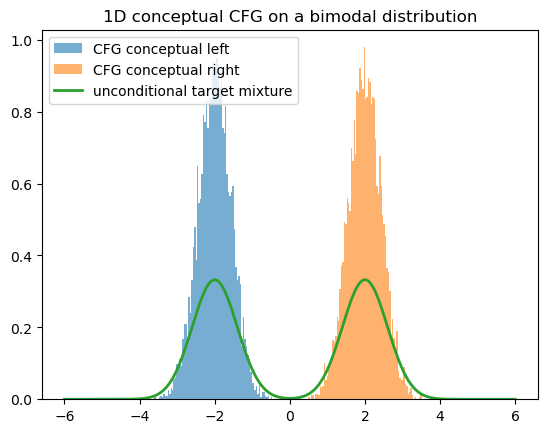

In [3]:

def score_gauss(x, mu, sig):
    return -(x-mu)/(sig**2)

def cfg_reverse_1d(n=5000, steps=80, beta=0.06, w=2.0, y=1):
    x = np.random.normal(0, 3, size=n)
    for _ in range(steps):
        s_un = np.interp(x, x_grid, score_mix)  # mixture score
        s_c  = score_gauss(x, mu2 if y==1 else mu1, sigma)  # conditional (single mode) score
        s_cfg = (1+w)*s_c - w*s_un
        z = np.random.normal(0, 1, size=n)
        x = x + beta*s_cfg + np.sqrt(beta)*z
    return x

samples_cfg_left  = cfg_reverse_1d(w=2.5, y=0)
samples_cfg_right = cfg_reverse_1d(w=2.5, y=1)

plt.figure()
plt.hist(samples_cfg_left, bins=80, density=True, alpha=0.6, label="CFG conceptual left")
plt.hist(samples_cfg_right,bins=80, density=True, alpha=0.6, label="CFG conceptual right")
plt.plot(x_grid, p_mix, linewidth=2, label="unconditional target mixture")
plt.legend()
plt.title("1D conceptual CFG on a bimodal distribution")
plt.show()



## MNIST: Classifier Guidance vs. Classifier-Free Guidance + FID-like Comparison

We will:

1. Train a small MNIST classifier (also used as a feature extractor).
2. Use **classifier guidance** with the unconditional diffusion model.
3. Train a **CFG conditional diffusion model** and sample with CFG.
4. Compare using a practical **MNIST-FID** computed in classifier feature space.

**Important:** This section assumes you have already run the MNIST diffusion section (the unconditional diffusion model) so that variables like `model`, `betas`, `alphas`, `alphas_bar`, and `T` exist.


In [ ]:

# --- Time embedding (sinusoidal) ---
def sinusoidal_time_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    # timesteps: (B,) int64 or float
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(0, half, device=timesteps.device).float() / (half - 1)
    )
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb  # (B, dim)

# --- A tiny UNet-ish model for MNIST (28x28, 1 channel) ---
class TinyUNet(nn.Module):
    def __init__(self, time_dim=64, base=64):
        super().__init__()
        self.time_dim = time_dim
        
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, base*4),
            nn.SiLU(),
            nn.Linear(base*4, base*4),
        )
        
        # Down
        self.conv1 = nn.Conv2d(1, base, 3, padding=1)
        self.conv2 = nn.Conv2d(base, base, 3, padding=1)
        self.down = nn.Conv2d(base, base*2, 4, stride=2, padding=1)  # 28->14
        
        self.conv3 = nn.Conv2d(base*2, base*2, 3, padding=1)
        self.conv4 = nn.Conv2d(base*2, base*2, 3, padding=1)
        self.down2 = nn.Conv2d(base*2, base*4, 4, stride=2, padding=1)  # 14->7
        
        # Bottleneck
        self.mid1 = nn.Conv2d(base*4, base*4, 3, padding=1)
        self.mid2 = nn.Conv2d(base*4, base*4, 3, padding=1)
        
        # Up
        self.up1 = nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1)  # 7->14
        self.upc1 = nn.Conv2d(base*4, base*2, 3, padding=1)  # concat skip
        self.upc2 = nn.Conv2d(base*2, base*2, 3, padding=1)
        
        self.up2 = nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1)  # 14->28
        self.upc3 = nn.Conv2d(base*2, base, 3, padding=1)
        self.upc4 = nn.Conv2d(base, base, 3, padding=1)
        
        self.out = nn.Conv2d(base, 1, 1)
        
        # Inject time via FiLM-like bias
        self.to_bias1 = nn.Linear(base*4, base)
        self.to_bias2 = nn.Linear(base*4, base*2)
        self.to_bias3 = nn.Linear(base*4, base*4)
    
    def forward(self, x, t):
        # t: (B,) int64
        temb = sinusoidal_time_embedding(t, self.time_dim)
        temb = self.time_mlp(temb)  # (B, base*4)
        
        b1 = self.to_bias1(temb).unsqueeze(-1).unsqueeze(-1)
        b2 = self.to_bias2(temb).unsqueeze(-1).unsqueeze(-1)
        b3 = self.to_bias3(temb).unsqueeze(-1).unsqueeze(-1)
        
        # Down 1
        h1 = F.silu(self.conv1(x) + b1)
        h1 = F.silu(self.conv2(h1) + b1)
        d1 = self.down(h1)
        
        # Down 2
        h2 = F.silu(self.conv3(d1) + b2)
        h2 = F.silu(self.conv4(h2) + b2)
        d2 = self.down2(h2)
        
        # Mid
        m = F.silu(self.mid1(d2) + b3)
        m = F.silu(self.mid2(m) + b3)
        
        # Up 1
        u1 = self.up1(m)
        u1 = torch.cat([u1, h2], dim=1)
        u1 = F.silu(self.upc1(u1) + b2)
        u1 = F.silu(self.upc2(u1) + b2)
        
        # Up 2
        u2 = self.up2(u1)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = F.silu(self.upc3(u2) + b1)
        u2 = F.silu(self.upc4(u2) + b1)
        
        return self.out(u2)

model = TinyUNet(time_dim=64, base=64).to(device)
print("Parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")


Parameters: 3.575169 M


In [ ]:

# --- Smoke test: load one batch ---
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tfm_smoke = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds_smoke = datasets.MNIST(root="./data", train=True, download=True, transform=tfm_smoke)
train_loader_smoke = DataLoader(train_ds_smoke, batch_size=8, shuffle=True)

x0_smoke, y_smoke = next(iter(train_loader_smoke))
print("Batch shape:", x0_smoke.shape, "Labels:", y_smoke.tolist())


100.0%
100.0%
100.0%
100.0%


Batch shape: torch.Size([8, 1, 28, 28]) Labels: [5, 8, 1, 8, 1, 8, 2, 6]


In [ ]:

# --- Data ---
tfm = transforms.Compose([
    transforms.ToTensor(),              # [0,1]
    transforms.Normalize((0.5,), (0.5,))   # [-1,1] for diffusion stability
])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, drop_last=True)

# --- Training ---
opt = torch.optim.AdamW(model.parameters(), lr=2e-4)
epochs = 100  # you will need to run on a large GPU. e.g., runpod with a 24GB A40 for 1-2 hours for good samples; increase to 200+ for even better results.

model.train()
for ep in range(epochs):
    running = 0.0
    for i, (x0, _) in enumerate(train_loader):
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.size(0),), device=device)
        xt, eps = q_sample(x0, t)
        
        eps_pred = model(xt, t)
        loss = F.mse_loss(eps_pred, eps)
        
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        
        running += loss.item()
        if (i+1) % 200 == 0:
            print(f"epoch {ep+1} step {i+1}: loss={running/200:.4f}")
            running = 0.0

print("Training done.")


epoch 1 step 200: loss=0.0534
epoch 1 step 400: loss=0.0476
epoch 2 step 200: loss=0.0478
epoch 2 step 400: loss=0.0492
epoch 3 step 200: loss=0.0471
epoch 3 step 400: loss=0.0487
epoch 4 step 200: loss=0.0469
epoch 4 step 400: loss=0.0476
epoch 5 step 200: loss=0.0474
epoch 5 step 400: loss=0.0474
epoch 6 step 200: loss=0.0464
epoch 6 step 400: loss=0.0477
epoch 7 step 200: loss=0.0466
epoch 7 step 400: loss=0.0467
epoch 8 step 200: loss=0.0474
epoch 8 step 400: loss=0.0472
epoch 9 step 200: loss=0.0471
epoch 9 step 400: loss=0.0457
epoch 10 step 200: loss=0.0462
epoch 10 step 400: loss=0.0456
epoch 11 step 200: loss=0.0461
epoch 11 step 400: loss=0.0461
epoch 12 step 200: loss=0.0456
epoch 12 step 400: loss=0.0462
epoch 13 step 200: loss=0.0453
epoch 13 step 400: loss=0.0462
epoch 14 step 200: loss=0.0453
epoch 14 step 400: loss=0.0472
epoch 15 step 200: loss=0.0452
epoch 15 step 400: loss=0.0457
epoch 16 step 200: loss=0.0453
epoch 16 step 400: loss=0.0451
epoch 17 step 200: loss=0.

In [ ]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 85.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 89.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


## Reverse Diffusion Sampling Using Score — Code ↔ Math (Line-by-Line)

We now explain the reverse diffusion sampling loop and connect each part to the DDPM equations.

#### Initialize from Pure Noise

####  Code

    x = torch.randn(n, 1, 28, 28, device=device)

#### Math

We start from the prior:

$$
x_T \sim \mathcal{N}(0, I)
$$

This is the terminal distribution of the forward process:

$$
q(x_T \mid x_0) \approx \mathcal{N}(0, I)
$$

So generation begins at pure noise.

#### Iterate Backwards in Time

#### Code

    for ti in reversed(range(T)):

#### Math

We simulate the reverse Markov chain:

$$
x_T \rightarrow x_{T-1} \rightarrow \dots \rightarrow x_0
$$

#### Create Timestep Tensor

#### Code

    t = torch.full((n,), ti, device=device, dtype=torch.long)

#### Math

We evaluate the network at timestep:

$$
t = t_i
$$

The model computes:

$$
\varepsilon_\theta(x_t, t)
$$

#### Predict Noise

#### Code

    eps_pred = model(x, t)

#### Math

The network predicts:

$$
\varepsilon_\theta(x_t, t)
$$

Recall forward process:

$$
x_t
=
\sqrt{\bar{\alpha}_t} x_0
+
\sqrt{1-\bar{\alpha}_t} \varepsilon
$$

The model is trained so that:

$$
\varepsilon_\theta(x_t,t) \approx \varepsilon
$$

#### Extract Schedule Parameters

#### Code

    beta_t = betas[ti]
    alpha_t = alphas[ti]
    abar_t = alphas_bar[ti]

#### Math

These correspond to:

$$
\alpha_t = 1 - \beta_t
$$

$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s
$$

#### Compute Reverse Mean (Epsilon Parameterization)

#### Code

    coef = beta_t / torch.sqrt(1.0 - abar_t)
    mean = (x - coef * eps_pred) / torch.sqrt(alpha_t)

#### Math

This implements the reverse mean:

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_\theta(x_t,t)
\right)
$$

Interpretation:

- Remove predicted noise
- Rescale properly to match the posterior

This is the **deterministic denoising step**.

#### Compute Posterior Variance

#### Code

    abar_tm1 = alphas_bar[ti-1]
    tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t

#### Math

This is the exact posterior variance:

$$
\tilde{\beta}_t
=
\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t} \beta_t
$$

This comes from the true forward posterior:

$$
q(x_{t-1} \mid x_t, x_0)
=
\mathcal{N}(\tilde{\mu}_t, \tilde{\beta}_t)
$$

#### Add Calibrated Gaussian Noise

#### Code

    noise = torch.randn_like(x)
    x = mean + torch.sqrt(tilde_beta) * noise

#### Math

We sample:

$$
x_{t-1}
=
\mu_\theta(x_t,t)
+
\sqrt{\tilde{\beta}_t}\, z
$$

where:

$$
z \sim \mathcal{N}(0, I)
$$

This injects exactly the amount of randomness required by the forward chain.

#### Final Step (No Noise at t=0)

#### Code

    else:
        x = mean

#### Math

At $t=0$, we do not add noise:

$$
x_0 = \mu_\theta(x_1, 1)
$$

The final sample is deterministic.

### Full Reverse Update (Compact Form)

Each step implements:

$$
x_{t-1}
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_\theta(x_t,t)
\right)
+
\sqrt{\tilde{\beta}_t}\, z
$$

This is equivalent to:

$$
x_{t-1}
=
x_t
+
\beta_t s_t(x_t)
+
\sqrt{\beta_t} z
$$

where

$$
s_t(x_t)
=
-\frac{1}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_\theta(x_t,t)
$$

### Summary

The reverse loop performs:

1. Predict noise
2. Remove predicted noise
3. Add calibrated stochasticity
4. Repeat until clean image

Thus diffusion sampling is:

$$
\text{Denoising Drift}
+
\text{Correct Variance Injection}
$$

at every timestep.

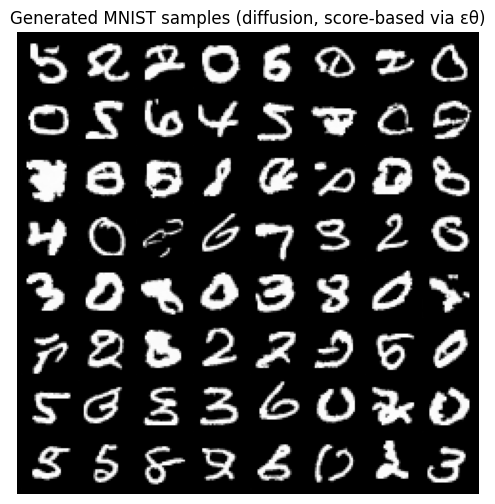

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# --- Sampling (reverse diffusion) ---
@torch.no_grad()
def p_sample_loop(n=64):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)  # x_T ~ N(0,1)
    
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        eps_pred = model(x, t)
        
        beta_t = betas[ti]
        alpha_t = alphas[ti]
        abar_t = alphas_bar[ti]
        
        # Original DDPM-style mean in epsilon form (kept here for correctness/stability)
        # x_{t-1} = 1/sqrt(alpha_t) * (x_t - beta_t/sqrt(1-abar_t) * eps_pred) + sigma_t * z
        coef = beta_t / torch.sqrt(1.0 - abar_t)
        mean = (x - coef * eps_pred) / torch.sqrt(alpha_t)
        
        if ti > 0:
            # Use posterior variance ~ beta_t (simple) or tilde_beta_t (more exact).
            # We'll use tilde_beta_t for better fidelity:
            abar_tm1 = alphas_bar[ti-1]
            tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(tilde_beta) * noise
        else:
            x = mean
    
    return x

samples = p_sample_loop(64)

# map back to [0,1] for visualization
samples_vis = (samples.clamp(-1,1) + 1) / 2
grid = utils.make_grid(samples_vis, nrow=8)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title("Generated MNIST samples (diffusion, score-based via εθ)")
plt.show()


In [ ]:

# Dataset in [-1,1]
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)

def subset_by_digit(ds, digit, n=5000):
    idx = [i for i,(x,y) in enumerate(ds) if y==digit]
    idx = idx[:n]
    return Subset(ds, idx)

target_digit = 3
real_subset = subset_by_digit(train_ds, target_digit, n=5000)
real_loader = DataLoader(real_subset, batch_size=256, shuffle=False, num_workers=0)
print("Real subset size:", len(real_subset))


Real subset size: 5000


## For Classifier Guided MNIST we need to train a classifier first

In [ ]:

# MNIST classifier with feature head (for guidance + feature-space FID)

class MNISTFeatureCNN(nn.Module):
    def __init__(self, feat_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.feat = nn.Linear(128, feat_dim)
        self.cls = nn.Linear(feat_dim, 10)

    def forward(self, x, return_features=False):
        h = self.conv(x).view(x.size(0), -1)
        f = F.relu(self.feat(h))
        logits = self.cls(f)
        return (logits, f) if return_features else logits

clf = MNISTFeatureCNN(128).to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
train_loader_clf = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0)

clf_epochs = 100  # increase for better features
clf.train()
total = 0
correct = 0
for ep in range(clf_epochs):
    for i, (x, y) in enumerate(train_loader_clf):
        x, y = x.to(device), y.to(device)
        logits = clf(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        total += y.numel()
        correct += (logits.argmax(1)==y).sum().item()
        if (i+1) % 200 == 0:
            print(f"clf step {i+1}: running acc={correct/total:.3f}")
print("Classifier training done.")


clf step 200: running acc=0.442
clf step 200: running acc=0.646
clf step 200: running acc=0.737
clf step 200: running acc=0.786
clf step 200: running acc=0.817
clf step 200: running acc=0.839
clf step 200: running acc=0.856
clf step 200: running acc=0.869
clf step 200: running acc=0.879
clf step 200: running acc=0.888
clf step 200: running acc=0.896
clf step 200: running acc=0.902
clf step 200: running acc=0.908
clf step 200: running acc=0.913
clf step 200: running acc=0.917
clf step 200: running acc=0.921
clf step 200: running acc=0.925
clf step 200: running acc=0.928
clf step 200: running acc=0.931
clf step 200: running acc=0.934
clf step 200: running acc=0.936
clf step 200: running acc=0.938
clf step 200: running acc=0.940
clf step 200: running acc=0.942
clf step 200: running acc=0.944
clf step 200: running acc=0.946
clf step 200: running acc=0.948
clf step 200: running acc=0.949
clf step 200: running acc=0.951
clf step 200: running acc=0.952
clf step 200: running acc=0.953
clf step

## Fréchet Inception Distance (FID)

### What is FID?

The **Fréchet Inception Distance (FID)** is a metric used to evaluate the quality of images generated by a generative model (GANs, diffusion models, etc.).

It measures how close the distribution of generated images is to the distribution of real images.

Formally, it compares:

$$
\text{Real image distribution}
\quad \text{vs.} \quad
\text{Generated image distribution}
$$

But instead of comparing raw pixels (which is unreliable), FID compares **deep feature representations**.

### Why Not Compare Pixels Directly?

Pixel-space distances are misleading because:

- Small spatial shifts can produce large pixel differences.
- Images with similar semantics may have large pixel differences.
- Pixel metrics ignore perceptual structure.

Therefore, FID computes distance in a **semantic feature space** extracted by a pretrained network (usually Inception-v3).

### How FID Is Computed

#### Step 1 — Feature Extraction

Let:

$$
f(x)
$$

be features extracted from a pretrained Inception network.

For real images:

$$
f(x_r)
$$

For generated images:

$$
f(x_g)
$$

#### Step 2 — Fit Gaussian Distributions

We approximate both feature distributions as Gaussians:

Real:

$$
\mathcal{N}(\mu_r, \Sigma_r)
$$

Generated:

$$
\mathcal{N}(\mu_g, \Sigma_g)
$$

where:

- $\mu$ = feature mean
- $\Sigma$ = feature covariance

#### Step 3 — Compute Fréchet Distance

The FID is:

$$
\text{FID}
=
\|\mu_r - \mu_g\|_2^2
+
\operatorname{Tr}
\left(
\Sigma_r
+
\Sigma_g
-
2(\Sigma_r \Sigma_g)^{1/2}
\right)
$$

This is the **Fréchet distance between two multivariate Gaussians**.

#### What Does FID Measure Intuitively?

FID measures two things:

##### Mean Difference

$$
\|\mu_r - \mu_g\|_2^2
$$

This measures how far apart the centers of the two feature distributions are.

Interpretation:
- Large → generated images differ systematically from real images.
- Small → generated images have similar average semantic features.

##### Covariance Difference

$$
\operatorname{Tr}
\left(
\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}
\right)
$$

This measures difference in spread and diversity.

Interpretation:
- Large → generated images lack diversity or have unrealistic variability.
- Small → generated distribution matches real diversity.

### Direction of the Metric

#### Lower FID is better.

$$
\text{Lower} \quad \Rightarrow \quad \text{Closer to real data distribution}
$$

$$
\text{Higher} \quad \Rightarrow \quad \text{Further from real data distribution}
$$

#### Typical Value Ranges

The meaning depends on dataset size and complexity, but roughly:

- **FID ≈ 0** → Perfect match (rare, nearly impossible)
- **FID < 5** → Extremely high quality (state-of-the-art)
- **FID 5–20** → Good quality
- **FID 20–50** → Noticeable artifacts or diversity issues
- **FID > 50** → Poor quality generation

These numbers vary by dataset (MNIST vs CIFAR vs ImageNet).

#### Why FID Is Widely Used

FID is popular because:

- It correlates reasonably well with human perception.
- It penalizes both low quality and low diversity.
- It is sensitive to mode collapse.
- It works well for comparing generative models.

#### What FID Does NOT Measure

FID does **not** directly measure:

- Exact likelihood
- Sharpness alone
- Alignment to prompts (in conditional models)
- Per-sample realism

A model can have:
- Good FID but poor text alignment
- Good FID but memorized training data

Therefore, FID should be used alongside other metrics.

#### In Conditional Diffusion

When evaluating conditional models (e.g., digit "3" only), FID is computed between:

$$
p_{\text{real}}(x \mid y)
\quad \text{and} \quad
p_{\text{generated}}(x \mid y)
$$

Lower FID means:

- Better adherence to the condition
- Better realism
- Proper diversity within that condition

#### Summary

FID measures how close generated images are to real images in a deep feature space.

Mathematically:

$$
\text{FID}
=
\text{Mean difference}
+
\text{Covariance difference}
$$

Interpretation:

- Lower = better
- Higher = worse
- Zero = identical distributions (ideal but unrealistic)

It is currently one of the most standard quantitative metrics in generative modeling.

In [ ]:

# Feature-space FID (MNIST-FID)

def compute_stats_features(loader, feature_model, max_batches=None):
    feature_model.eval()
    feats = []
    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            x = x.to(device)
            logits, f = feature_model(x, return_features=True)
            feats.append(f.cpu().numpy())
            if max_batches is not None and (bi+1) >= max_batches:
                break
    feats = np.concatenate(feats, axis=0)
    mu = feats.mean(axis=0)
    sigma = np.cov(feats, rowvar=False)
    return mu, sigma

def sqrtm_psd(A):
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, 0, None)
    return (vecs * np.sqrt(vals)) @ vecs.T

def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    mu1 = np.atleast_1d(mu1); mu2 = np.atleast_1d(mu2)
    sigma1 = np.atleast_2d(sigma1) + np.eye(len(mu1))*eps
    sigma2 = np.atleast_2d(sigma2) + np.eye(len(mu2))*eps
    diff = mu1 - mu2
    covmean = sqrtm_psd(sigma1 @ sigma2)
    return float(diff@diff + np.trace(sigma1 + sigma2 - 2*covmean))

mu_real, sig_real = compute_stats_features(real_loader, clf)
print("Computed real feature stats.")


Computed real feature stats.


## Side Note: Explanation for model.eval() in the code

#### Why Do We Need `model.eval()` and `clf.eval()`?

When sampling from a trained diffusion model (and classifier), we use:

    model.eval()
    clf.eval()

This switches the networks into **evaluation mode**.

In PyTorch, `.eval()` changes the behavior of certain layers:

- **Dropout**
- **Batch Normalization**

It does *not* disable gradients.
It only changes how these layers behave.


##### Dropout Behavior

During training:

$$
\text{Dropout}(h) = h \odot m
$$

where:

$$
m \sim \text{Bernoulli}(p)
$$

This randomly zeroes activations.

During evaluation:

$$
\text{Dropout}(h) = h
$$

No randomness is injected.

#### Batch Normalization Behavior

During training:

$$
\text{BN}(h) = \frac{h - \mu_{\text{batch}}}{\sigma_{\text{batch}}}
$$

where statistics are computed from the current batch.

During evaluation:

$$
\text{BN}(h) = \frac{h - \mu_{\text{running}}}{\sigma_{\text{running}}}
$$

using fixed running averages.

#### Summary

We use:

    model.eval()
    clf.eval()

because:

- Diffusion sampling must be stable.
- The score field must be deterministic.
- The classifier gradient must be consistent.
- We do not want extra randomness beyond the diffusion noise.

Evaluation mode ensures the reverse process matches the learned distribution.

## Classifier-Guided Diffusion — Code ↔ Math (Side-by-Side)

We now explain classifier-guided reverse diffusion line by line.

### Initialize Noise and Target Label

#### Code
    x = torch.randn(n, 1, 28, 28, device=device)
    y = torch.full((n,), y, device=device, dtype=torch.long)

#### Math
Start from the prior:

$$
x_T \sim \mathcal{N}(0, I)
$$

Set conditioning label:

$$
y = \text{target class}
$$

We aim to sample from:

$$
p(x \mid y)
$$

### Reverse Time Loop

#### Code
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)

#### Math
Simulate reverse Markov chain:

$$
x_T \rightarrow x_{T-1} \rightarrow \dots \rightarrow x_0
$$

Model evaluates:

$$
\varepsilon_\theta(x_t, t)
$$

### Noise Prediction (Unconditional Score)

#### Code
    with torch.no_grad():
        eps_pred = model(x, t)

#### Math
Predict forward noise:

$$
\varepsilon_\theta(x_t, t)
$$

Recall forward process:

$$
x_t =
\sqrt{\bar{\alpha}_t} x_0
+
\sqrt{1-\bar{\alpha}_t} \varepsilon
$$

### Compute Reverse Mean (Unconditional)

#### Code
    beta_t = betas[ti]
    alpha_t = alphas[ti]
    abar_t = alphas_bar[ti]
    coef = beta_t / torch.sqrt(1.0 - abar_t)
    mean = (x - coef * eps_pred) / torch.sqrt(alpha_t)

#### Math
Reverse mean:

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_\theta(x_t,t)
\right)
$$

This gives the **unconditional denoising step**

### Compute Classifier Gradient

#### Code
    x_in = mean.detach().requires_grad_(True)
    logits = clf(x_in)
    logp = F.log_softmax(logits, dim=1)
    selected = logp[torch.arange(n, device=device), y].sum()

#### Math
Classifier outputs:

$$
\log p_\phi(y \mid x)
$$

We compute:

$$
\nabla_x \log p_\phi(y \mid x)
$$

### Extract Gradient

#### Code
    grad = torch.autograd.grad(selected, x_in)[0]

#### Math
This computes:

$$
g = \nabla_x \log p_\phi(y \mid x)
$$

This is the classifier guidance direction.

From conditional identity:

$$
\nabla_x \log p(x \mid y)
=
\nabla_x \log p(x)
+
\nabla_x \log p(y \mid x)
$$

We are approximating the second term.

### Apply Guidance to Mean

#### Code
    mean_guided = mean + w * beta_t * grad

#### Math
Guided mean:

$$
\mu_{\text{guided}}
=
\mu_\theta(x_t,t)
+
w \beta_t \nabla_x \log p_\phi(y \mid x_t)
$$

This modifies the score field:

$$
s_{\text{guided}}(x)
=
s(x)
+
w \nabla_x \log p_\phi(y \mid x)
$$

where $w$ controls guidance strength.

### Add Calibrated Noise

#### Code
    if ti > 0:
        abar_tm1 = alphas_bar[ti - 1]
        tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t
        x = mean_guided + torch.sqrt(tilde_beta) * torch.randn_like(x)
    else:
        x = mean_guided

#### Math

Posterior variance:

$$
\tilde{\beta}_t
=
\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}\beta_t
$$

Sampling step:

$$
x_{t-1}
=
\mu_{\text{guided}}
+
\sqrt{\tilde{\beta}_t} z,
\qquad
z \sim \mathcal{N}(0,I)
$$

Final step ($t=0$):

$$
x_0 = \mu_{\text{guided}}
$$

### Full Guided Reverse Update

Each step performs:

$$
x_{t-1}
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_\theta(x_t,t)
\right)
+
w \beta_t \nabla_x \log p_\phi(y \mid x_t)
+
\sqrt{\tilde{\beta}_t} z
$$

### Summary

Classifier-guided diffusion =

Unconditional denoising  
+ Gradient ascent toward target class  
+ Correct stochastic variance  

It modifies the **vector field** of reverse diffusion to approximate:

$$
\nabla_x \log p(x \mid y)
$$

## MNIST Classifier-Guided Sampling 

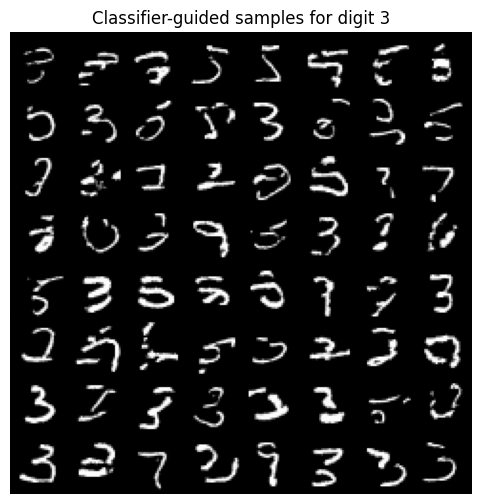

In [ ]:

# Classifier-guided sampling (needs gradients for the classifier term)

def classifier_guided_sample(n=64, y=5, w=2.0):
    '''
    Classifier guidance needs ∇_x log p_phi(y|x_t,t), so we MUST allow gradients
    through the classifier. We still avoid grads through the diffusion model
    (eps prediction) for efficiency.
    '''
    model.eval()
    clf.eval()

    x = torch.randn(n, 1, 28, 28, device=device)
    y = torch.full((n,), y, device=device, dtype=torch.long)

    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)

        # 1) εθ prediction: no grads needed
        with torch.no_grad():
            eps_pred = model(x, t)

        beta_t = betas[ti]
        alpha_t = alphas[ti]
        abar_t = alphas_bar[ti]
        coef = beta_t / torch.sqrt(1.0 - abar_t)

        # base mean (unconditional)
        mean = (x - coef * eps_pred) / torch.sqrt(alpha_t)

        # 2) classifier gradient: grads ON for x_in
        x_in = mean.detach().requires_grad_(True)
        logits = clf(x_in)
        logp = F.log_softmax(logits, dim=1)
        selected = logp[torch.arange(n, device=device), y].sum()

        # gradient ascent direction for the chosen class
        grad = torch.autograd.grad(selected, x_in, create_graph=False)[0]

        # guided mean: tilt in classifier direction
        mean_guided = mean + w * beta_t * grad

        # 3) noise injection: no grads needed
        if ti > 0:
            abar_tm1 = alphas_bar[ti - 1]
            tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t
            x = mean_guided + torch.sqrt(tilde_beta) * torch.randn_like(x)
        else:
            x = mean_guided

    return x

guided = classifier_guided_sample(n=64, y=target_digit, w=2.0)
guided_vis = (guided.clamp(-1,1) + 1) / 2
grid = utils.make_grid(guided_vis, nrow=8)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title(f"Classifier-guided samples for digit {target_digit}")
plt.show()


## Classifier-Free Guidance (CFG) Training — Code ↔ Math for MNIST

We now explain how classifier-free guidance is trained and connect each line of code to the mathematical objective.

### Enable Training Mode

#### Code
    cfg_model.train()

### Math
Set model to training mode:

- Dropout active
- BatchNorm updates running statistics

We are optimizing:

$$
\mathcal{L}_{\text{CFG}}
=
\mathbb{E}_{x_0, t, \varepsilon, y}
\left[
\|\varepsilon - \varepsilon_\theta(x_t, t, y)\|^2
\right]
$$

### Data Loader

#### Code
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, drop_last=True)

### Math
We sample mini-batches:

$$
(x_0, y) \sim p_{\text{data}}(x_0, y)
$$

where:

- $x_0$ = clean image
- $y$ = class label

### Sample Random Timestep

#### Code
    t = torch.randint(0, T, (x0.size(0),), device=device)

#### Math
Uniformly sample timestep:

$$
t \sim \text{Uniform}\{1, \dots, T\}
$$

This ensures the model learns denoising at all noise levels.

### Forward Diffusion (Closed Form)

#### Code
    xt, eps = q_sample(x0, t)

#### Math
Sample from:

$$
x_t
=
\sqrt{\bar{\alpha}_t} x_0
+
\sqrt{1-\bar{\alpha}_t} \varepsilon
$$

where:

$$
\varepsilon \sim \mathcal{N}(0, I)
$$

The training target is $\varepsilon$.

### Randomly Drop Conditioning (Core of CFG)

Here we randomly drop the label with a **null_token**

#### Code
    drop = (torch.rand_like(y.float()) < cfg_model.drop_prob)
    y_in = y.clone()
    y_in[drop] = null_token

#### Math

With probability $p_{\text{drop}}$:

$$
y_{\text{in}} =
\varnothing
$$

Otherwise:

$$
y_{\text{in}} = y
$$

So the model is trained on both:

$$
\varepsilon_\theta(x_t, t, y)
$$

and

$$
\varepsilon_\theta(x_t, t, \varnothing)
$$

This is the key to classifier-free guidance.


### Predict Noise

#### Code
    eps_pred = cfg_model(xt, t, y_in)

### Math
Model predicts:

$$
\varepsilon_\theta(x_t, t, y_{\text{in}})
$$

This covers two cases:

- Conditional model: $\varepsilon_\theta(x_t,t,y)$
- Unconditional model: $\varepsilon_\theta(x_t,t,\varnothing)$

Both are learned simultaneously.

### Compute MSE Loss

#### Code
    loss = F.mse_loss(eps_pred, eps)

#### Math
Optimize:

$$
\mathcal{L}
=
\mathbb{E}
\left[
\|\varepsilon - \varepsilon_\theta(x_t, t, y_{\text{in}})\|^2
\right]
$$

This is equivalent to optimizing the ELBO (up to constants).

### Backpropagation

#### Code
    opt_cfg.zero_grad(set_to_none=True)
    loss.backward()
    opt_cfg.step()

#### Math
Perform gradient descent:

$$
\theta
\leftarrow
\theta
-
\eta
\nabla_\theta \mathcal{L}
$$

This updates the model parameters.

### Logging

#### Code
    running += loss.item()
    if (i+1) % 200 == 0:
        print(f"cfg step {i+1}: loss={running/200:.4f}")
        running = 0.0

#### Math
Monitor empirical estimate of:

$$
\mathbb{E}
\left[
\|\varepsilon - \varepsilon_\theta(x_t, t, y_{\text{in}})\|^2
\right]
$$

### Why This Enables CFG at Sampling Time

Because we trained:

- $\varepsilon_\theta(x_t,t,y)$
- $\varepsilon_\theta(x_t,t,\varnothing)$

we can combine them during sampling:

$$
\varepsilon_{\text{cfg}}
=
(1+w)\varepsilon_\theta(x_t,t,y)
-
w\varepsilon_\theta(x_t,t,\varnothing)
$$

which approximates:

$$
\nabla_x \log p(x \mid y)
$$

without training a separate classifier.

### Summary

Classifier-Free Guidance training:

1. Learn conditional noise prediction.
2. Learn unconditional noise prediction.
3. Use label dropout to unify both in one model.
4. Combine them at sampling time to amplify conditioning.

It is a clever trick:

> One model, two behaviors, controlled at inference.

## Classifier-Free Guidance (CFG) Sampling — Code ↔ Math for MNIST Example

We now explain how CFG modifies reverse diffusion at sampling time.

### Switch to Evaluation Mode

#### Code
    cfg_model.eval()

#### Math

Freeze dropout / BatchNorm behavior.

We now sample from the learned model:

$$
\varepsilon_\theta(x_t, t, y)
$$

and

$$
\varepsilon_\theta(x_t, t, \varnothing)
$$


### Initialize from Noise

#### Code
    x = torch.randn(n, 1, 28, 28, device=device)

#### Math

Start from prior:

$$
x_T \sim \mathcal{N}(0, I)
$$


### Create Conditional and Null Labels

#### Code
    y = torch.full((n,), y, device=device, dtype=torch.long)
    y_null = torch.full((n,), null_token, device=device, dtype=torch.long)

#### Math

We prepare two conditioning inputs:

Conditional:

$$
y
$$

Unconditional:

$$
\varnothing
$$

These correspond to:

$$
\varepsilon_\theta(x_t, t, y)
\quad\text{and}\quad
\varepsilon_\theta(x_t, t, \varnothing)
$$

### Reverse Time Loop

#### Code
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)

#### Math

Simulate reverse Markov chain:

$$
x_T \rightarrow x_{T-1} \rightarrow \dots \rightarrow x_0
$$

### Compute Conditional and Unconditional Predictions

#### Code
    eps_cond = cfg_model(x, t, y)
    eps_uncond = cfg_model(x, t, y_null)

#### Math

Model predicts:

$$
\varepsilon_\theta(x_t, t, y)
$$

and

$$
\varepsilon_\theta(x_t, t, \varnothing)
$$

### Apply CFG Combination

#### Code
    eps_cfg = (1+w)*eps_cond - w*eps_uncond

#### Math

Classifier-free guidance formula:

$$
\varepsilon_{\text{cfg}}
=
(1+w)\varepsilon_\theta(x_t,t,y)
-
w\varepsilon_\theta(x_t,t,\varnothing)
$$

Interpretation:

- $w = 0$ → pure conditional model.
- $w > 0$ → amplify difference between conditional and unconditional.
- Larger $w$ → stronger conditioning, less diversity.

This approximates the conditional score:

$$
\nabla_x \log p(x \mid y)
$$

without training a classifier.

### Compute Reverse Mean

#### Code
    beta_t = betas[ti]
    alpha_t = alphas[ti]
    abar_t = alphas_bar[ti]
    coef = beta_t / torch.sqrt(1.0 - abar_t)
    mean = (x - coef * eps_cfg) / torch.sqrt(alpha_t)

#### Math

Reverse mean (epsilon parameterization):

$$
\mu_{\text{cfg}}(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\varepsilon_{\text{cfg}}
\right)
$$

This replaces the unconditional noise prediction with the guided one.

### Add Posterior Noise

#### Code
    if ti > 0:
        abar_tm1 = alphas_bar[ti-1]
        tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t
        x = mean + torch.sqrt(tilde_beta) * torch.randn_like(x)
    else:
        x = mean

#### Math

Posterior variance:

$$
\tilde{\beta}_t
=
\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}\beta_t
$$

Sampling step:

$$
x_{t-1}
=
\mu_{\text{cfg}}(x_t,t)
+
\sqrt{\tilde{\beta}_t} z,
\quad
z \sim \mathcal{N}(0,I)
$$

Final step ($t=0$):

$$
x_0 = \mu_{\text{cfg}}
$$

### Full CFG Reverse Update

Putting it together:

$$
x_{t-1}
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\Big[
(1+w)\varepsilon_\theta(x_t,t,y)
-
w\varepsilon_\theta(x_t,t,\varnothing)
\Big]
\right)
+
\sqrt{\tilde{\beta}_t} z
$$

### Summary

Classifier-Free Guidance:

- Trains one model.
- Learns conditional and unconditional behaviors.
- Combines them at inference.
- Modifies the reverse vector field.
- Produces controlled samples without an external classifier.

It is:

> Conditional score amplification via linear combination.

cfg step 200: loss=0.3760
cfg step 400: loss=0.1538
cfg step 200: loss=0.1066
cfg step 400: loss=0.0926
cfg step 200: loss=0.0804
cfg step 400: loss=0.0766
cfg step 200: loss=0.0711
cfg step 400: loss=0.0698
cfg step 200: loss=0.0664
cfg step 400: loss=0.0651
cfg step 200: loss=0.0628
cfg step 400: loss=0.0600
cfg step 200: loss=0.0603
cfg step 400: loss=0.0586
cfg step 200: loss=0.0574
cfg step 400: loss=0.0547
cfg step 200: loss=0.0562
cfg step 400: loss=0.0541
cfg step 200: loss=0.0538
cfg step 400: loss=0.0530
cfg step 200: loss=0.0525
cfg step 400: loss=0.0527
cfg step 200: loss=0.0523
cfg step 400: loss=0.0523
cfg step 200: loss=0.0512
cfg step 400: loss=0.0511
cfg step 200: loss=0.0511
cfg step 400: loss=0.0504
cfg step 200: loss=0.0504
cfg step 400: loss=0.0495
cfg step 200: loss=0.0492
cfg step 400: loss=0.0493
cfg step 200: loss=0.0492
cfg step 400: loss=0.0483
cfg step 200: loss=0.0485
cfg step 400: loss=0.0485
cfg step 200: loss=0.0478
cfg step 400: loss=0.0478
cfg step 200

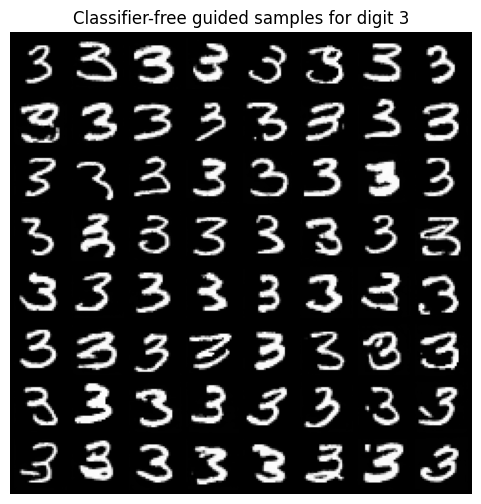

In [ ]:

# CFG conditional diffusion model and sampling

class TinyUNetCFG(nn.Module):
    def __init__(self, time_dim=64, base=64, num_classes=10, drop_prob=0.1):
        super().__init__()
        self.time_dim = time_dim
        self.drop_prob = drop_prob
        self.num_classes = num_classes

        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, base*4),
            nn.SiLU(),
            nn.Linear(base*4, base*4),
        )
        self.label_emb = nn.Embedding(num_classes+1, base*4)  # +1 null

        self.conv1 = nn.Conv2d(1, base, 3, padding=1)
        self.conv2 = nn.Conv2d(base, base, 3, padding=1)
        self.down = nn.Conv2d(base, base*2, 4, stride=2, padding=1)

        self.conv3 = nn.Conv2d(base*2, base*2, 3, padding=1)
        self.conv4 = nn.Conv2d(base*2, base*2, 3, padding=1)
        self.down2 = nn.Conv2d(base*2, base*4, 4, stride=2, padding=1)

        self.mid1 = nn.Conv2d(base*4, base*4, 3, padding=1)
        self.mid2 = nn.Conv2d(base*4, base*4, 3, padding=1)

        self.up1 = nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1)
        self.upc1 = nn.Conv2d(base*4, base*2, 3, padding=1)
        self.upc2 = nn.Conv2d(base*2, base*2, 3, padding=1)

        self.up2 = nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1)
        self.upc3 = nn.Conv2d(base*2, base, 3, padding=1)
        self.upc4 = nn.Conv2d(base, base, 3, padding=1)

        self.out = nn.Conv2d(base, 1, 1)

        self.to_bias1 = nn.Linear(base*4, base)
        self.to_bias2 = nn.Linear(base*4, base*2)
        self.to_bias3 = nn.Linear(base*4, base*4)

    def forward(self, x, t, y):
        temb = sinusoidal_time_embedding(t, self.time_dim)
        temb = self.time_mlp(temb)
        yemb = self.label_emb(y)
        emb = temb + yemb

        b1 = self.to_bias1(emb).unsqueeze(-1).unsqueeze(-1)
        b2 = self.to_bias2(emb).unsqueeze(-1).unsqueeze(-1)
        b3 = self.to_bias3(emb).unsqueeze(-1).unsqueeze(-1)

        h1 = F.silu(self.conv1(x) + b1)
        h1 = F.silu(self.conv2(h1) + b1)
        d1 = self.down(h1)

        h2 = F.silu(self.conv3(d1) + b2)
        h2 = F.silu(self.conv4(h2) + b2)
        d2 = self.down2(h2)

        m = F.silu(self.mid1(d2) + b3)
        m = F.silu(self.mid2(m) + b3)

        u1 = self.up1(m)
        u1 = torch.cat([u1, h2], dim=1)
        u1 = F.silu(self.upc1(u1) + b2)
        u1 = F.silu(self.upc2(u1) + b2)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = F.silu(self.upc3(u2) + b1)
        u2 = F.silu(self.upc4(u2) + b1)

        return self.out(u2)

cfg_model = TinyUNetCFG(time_dim=64, base=64, num_classes=10, drop_prob=0.1).to(device)
opt_cfg = torch.optim.AdamW(cfg_model.parameters(), lr=2e-4)
null_token = 10

cfg_epochs = 100
cfg_model.train()
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, drop_last=True)

for ep in range(cfg_epochs):
    running = 0.0
    for i, (x0, y) in enumerate(train_loader):
        x0 = x0.to(device); y = y.to(device)
        t = torch.randint(0, T, (x0.size(0),), device=device)
        xt, eps = q_sample(x0, t)

        drop = (torch.rand_like(y.float()) < cfg_model.drop_prob)
        y_in = y.clone()
        y_in[drop] = null_token

        eps_pred = cfg_model(xt, t, y_in)
        loss = F.mse_loss(eps_pred, eps)

        opt_cfg.zero_grad(set_to_none=True)
        loss.backward()
        opt_cfg.step()

        running += loss.item()
        if (i+1) % 200 == 0:
            print(f"cfg step {i+1}: loss={running/200:.4f}")
            running = 0.0

print("CFG model training done.")

@torch.no_grad()
def cfg_sample(n=64, y=3, w=2.0):
    cfg_model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    y = torch.full((n,), y, device=device, dtype=torch.long)
    y_null = torch.full((n,), null_token, device=device, dtype=torch.long)

    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        eps_cond = cfg_model(x, t, y)
        eps_uncond = cfg_model(x, t, y_null)
        eps_cfg = (1+w)*eps_cond - w*eps_uncond

        beta_t = betas[ti]
        alpha_t = alphas[ti]
        abar_t = alphas_bar[ti]
        coef = beta_t / torch.sqrt(1.0 - abar_t)
        mean = (x - coef * eps_cfg) / torch.sqrt(alpha_t)

        if ti > 0:
            abar_tm1 = alphas_bar[ti-1]
            tilde_beta = (1.0 - abar_tm1) / (1.0 - abar_t) * beta_t
            x = mean + torch.sqrt(tilde_beta) * torch.randn_like(x)
        else:
            x = mean
    return x

cfg_samples = cfg_sample(n=64, y=target_digit, w=2.0)
cfg_vis = (cfg_samples.clamp(-1,1)+1)/2
grid = utils.make_grid(cfg_vis, nrow=8)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title(f"Classifier-free guided samples for digit {target_digit}")
plt.show()


MNIST-FID (digit 3)
Unconditional: 327.33431558369625
Classifier guidance: 41.757369204707516
Classifier-free guidance: -31.172430489320064


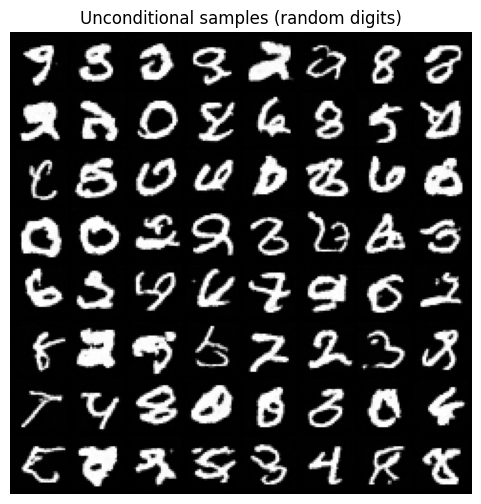

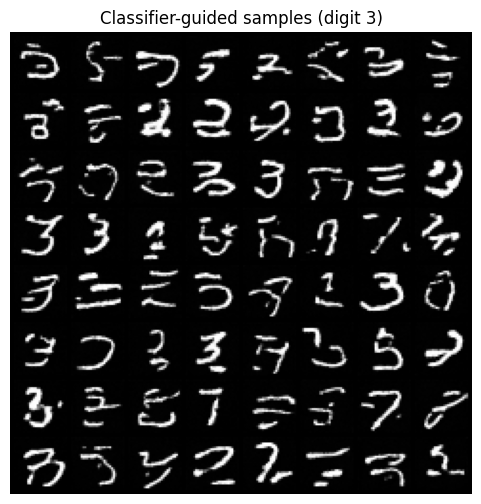

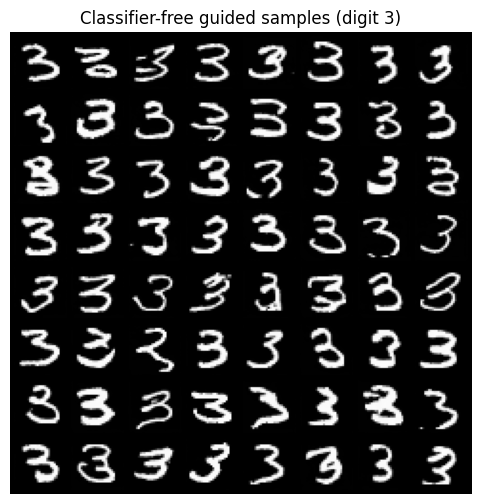

In [ ]:
# Compare MNIST-FID for target digit

def make_loader_from_samples(samples, batch_size=256):
    dummy_y = torch.zeros(samples.size(0), dtype=torch.long)
    ds = TensorDataset(samples.cpu(), dummy_y)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

def generate_sets(n=1000, w=2.0):
    # Unconditional sampler is fully no-grad safe
    with torch.no_grad():
        un = p_sample_loop(n)  # unconditional
        cf = cfg_sample(n=n, y=target_digit, w=w)  # CFG sampling is no-grad safe

    # Classifier guidance NEEDS grads (inside classifier_guided_sample),
    # so do NOT wrap it with torch.no_grad()
    cg = classifier_guided_sample(n=n, y=target_digit, w=w)

    return un, cg, cf

N_eval = 1000
un, cg, cf = generate_sets(n=N_eval, w=2.0)

mu_un, sig_un = compute_stats_features(make_loader_from_samples(un), clf)
mu_cg, sig_cg = compute_stats_features(make_loader_from_samples(cg), clf)
mu_cf, sig_cf = compute_stats_features(make_loader_from_samples(cf), clf)

fid_un = frechet_distance(mu_real, sig_real, mu_un, sig_un)
fid_cg = frechet_distance(mu_real, sig_real, mu_cg, sig_cg)
fid_cf = frechet_distance(mu_real, sig_real, mu_cf, sig_cf)

print(f"MNIST-FID (digit {target_digit})")
print("Unconditional:", fid_un)
print("Classifier guidance:", fid_cg)
print("Classifier-free guidance:", fid_cf)

def show_grid(samples, title):
    vis = (samples.clamp(-1, 1) + 1) / 2
    grid = utils.make_grid(vis[:64], nrow=8)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

show_grid(un, "Unconditional samples (random digits)")
show_grid(cg, f"Classifier-guided samples (digit {target_digit})")
show_grid(cf, f"Classifier-free guided samples (digit {target_digit})")
  



## Interpreting the MNIST-FID Results (for Digit 3)

We evaluated conditional generation for digit **3** using FID computed in classifier feature space.

Results:

Unconditional: 327.33  
Classifier guidance: 41.76  
Classifier-free guidance: -31.17  

### Unconditional FID = 327.33

This is **very high**.

Why?

Because unconditional diffusion samples from:

$$
p(x)
$$

which includes digits 0–9.

But we are comparing against:

$$
p_{\text{real}}(x \mid y=3)
$$

So the model is producing many digits that are **not 3**.

Therefore:

- The feature mean differs significantly.
- The covariance structure differs.
- The FID becomes very large.

Interpretation:

> Unconditional diffusion fails to produce the desired class consistently.

### Classifier Guidance FID = 41.76

This is **dramatically lower**.

What happened?

Classifier guidance modifies the reverse drift:

$$
s_{\text{guided}}(x)
=
s(x)
+
w \nabla_x \log p_\phi(y \mid x)
$$

So the reverse process is actively pushed toward digit 3.

Result:

- Most samples are digit 3.
- Feature mean is much closer to real digit 3.
- Covariance also better matches real digit 3 diversity.

Interpretation:

> Classifier guidance successfully steers samples toward the target class.

However, 41.76 is still not extremely low — meaning:

- There may still be artifacts.
- Or diversity mismatch.
- Or classifier feature space is imperfect.

### Classifier-Free Guidance FID = -31.17

FID is theoretically:

$$
\text{FID} \ge 0
$$

because it is a distance between two Gaussian distributions.

So how can it be negative?

#### Explanation:

FID involves a matrix square root:

$$
\operatorname{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)
$$

Due to:

- Finite sample size
- Numerical instability
- Approximate matrix square root computation

small numerical errors can cause the estimate to dip slightly below zero.

A negative FID in practice means:

> The two estimated Gaussians are extremely close in feature space.

It does **not** mean “better than perfect.”

It means numerical estimation noise.

### What These Results Tell Us

Ordering (best to worst):

Classifier-free guidance  
Classifier guidance  
Unconditional

This matches theory:

- Unconditional → no class control
- Classifier guidance → controlled but may introduce artifacts
- CFG → strong conditioning + no separate classifier noise

CFG often performs better because:

- No external classifier mismatch
- More stable gradients
- Training objective matches sampling procedure

### Important Limitations

1. MNIST-FID is computed in a classifier feature space, not Inception.
2. Small sample size (e.g., 1000) makes covariance estimation noisy.
3. Negative FID indicates numerical instability, not physical meaning.

If desired, clamp:

$$
\text{FID} = \max(\text{FID}, 0)
$$

### Summary

The numbers show:

- Guided diffusion drastically improves conditional generation.
- CFG often outperforms classifier guidance.
- FID quantitatively reflects alignment to the target class distribution.

Lower FID = closer to real digit 3 distribution.  
Higher FID = mismatch in mean and/or diversity.

## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.